# Generating lognormal and Gaussian fields correlated with input ACT CMB lensing maps.

In this notebook we show how to generate a field using the fieldgen package.

We will focus just on the galaxy density field.

The generated density field will be correlated with the ACT CMB lensing fields. So no need for any noise treatment.

The signal part of the field can be:

* lognormal
* Gaussian

For any questions or bugs o.darwish@proton.me

In [1]:
# Here we import useful packages that will be used throught the notebook

import healpy as hp

from plancklens.utils import alm_copy
from plancklens import shts

import numpy as np

import pathlib

%reload_ext autoreload
%autoreload 2

from fieldgen import lognormal, conditionedsims as cs, utils as fgutils, logutils

import matplotlib.pyplot as plt
#retina display
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12


Using lenspyx alm2map


### First of all, let's setup some general things

In [2]:
#lambdas = np.array([2.7, 1.089, 1.106, 0.0085] )#0.0085]) #1.089, 1.106])

Ngalaxyfields = 6
Nshearfields = 4
Nfields = Ngalaxyfields+Nshearfields #6 is galaxies, 4 is shear

fixed_index = Nfields
Nfields += 1 #for CMB lensing

print('Number of fields:', Nfields)

lambdas_gcgc = np.array([1.089,1.106,1.046,1.252,1.177,1.177])
#lambdas_gsgs = np.array([0.00453, 0.00885, 0.021, 0.033])
lambdas_gsgs = np.array([0.00453, 0.00885, 0.022, 0.034]) #np.array([0.00453, 0.00885, 0.022, 0.034])
lambda_cmbl = np.array([3]) #np.array([2.7]) #2.7
lambdas = np.concatenate([lambda_cmbl, lambdas_gcgc, lambdas_gsgs])
lambdas = lambdas[:Nfields]
print(lambdas) 

Nfields = len(lambdas)

print('Number of fields:', Nfields)

seed = 144

#maps
nside = 2048

lmax = 3*nside-1

fixed_index = Nfields-1 #fixed index for the CMB lensing convergence field

Number of fields: 11
[3.      1.089   1.106   1.046   1.252   1.177   1.177   0.00453 0.00885
 0.022   0.034  ]
Number of fields: 11


## Let's get an input lensing map

### Now, let's get some spectra

In [140]:
def prepare_get_functions_for_conditioned_sims(theoryinputdir, lmax = 3072, keyfunction = None):

    """clkk = np.zeros(lmax)
    size = np.loadtxt(pathlib.Path(theoryinputdir/"clkk_input.dat")).shape[0]
    index = min(size, lmax)
    clkk[:index] = np.loadtxt(pathlib.Path(theoryinputdir/"clkk_input.dat"))[:index]"""

    """cppofficial = np.loadtxt("cosmo2017_10K_acc3_lenspotentialCls.dat").T[5]
    cppofficial = np.concatenate([np.zeros(2), cppofficial])
    ls = np.arange(cppofficial.size)
    factorA = (ls*(ls + 1))**2/(2*np.pi)
    factorB = (ls*(ls + 1)/(2))**2.
    factor = factorB/factorA
    clkk = cppofficial*factor
    clkk[0] = 0

    size = clkk.size
    index = min(size, lmax)
    clkk[:index] = clkk[:index]"""


    size = np.loadtxt(pathlib.Path(theoryinputdir/"cl_kk.txt")).T[1].shape[0]
    index = min(size, lmax)
    clkk = np.loadtxt(pathlib.Path(theoryinputdir/"cl_kk.txt")).T[1][:index]

    get_kk = lambda: clkk[:index]

    index = lmax

    get_kg = lambda b: np.loadtxt(theoryinputdir/f'cl_k{keyfunction(b)}_{keymap(b)}.txt').T[1][:index]


    def get_gg(a, b):
        allow = keyfunction(a) == keyfunction(b)
        allow *= (keymap(a) == keymap(b))
        allow = 1
        try:
            return np.loadtxt(theoryinputdir/f'cl_{keyfunction(a)}{keyfunction(b)}_{keymap(a)}_{keymap(b)}.txt').T[1][:index]*allow
        except:
            return np.loadtxt(theoryinputdir/f'cl_{keyfunction(b)}{keyfunction(a)}_{keymap(b)}_{keymap(a)}.txt').T[1][:index]*allow
    
    return get_kk, get_kg, get_gg


def get_get_AB(theoryinputdir, fixed_index = 0, lmax = 6000, nside = 1024, apply_pixwin = True, keyfunction = None, keymap = None):
    #lmax = min(lmax, 3*nside)

    get_kk, get_kg, get_gg = prepare_get_functions_for_conditioned_sims(theoryinputdir, lmax, keyfunction = keyfunction)

    pixwin = hp.pixwin(nside, lmax = lmax) if apply_pixwin else 1.0
    size = pixwin.size
    size = min(size, lmax)
    pixwin = pixwin[:size]

    def get_AB(a, b):
        if (a == fixed_index) or (b == fixed_index):
            if a == b:
                return get_kk()[:size]
            elif a == fixed_index:
                return get_kg(b)[:size]*pixwin
            else:
                return get_kg(a)[:size]*pixwin
        else:
            return get_gg(a, b)[:size]*pixwin**2
    return get_AB

In [141]:
spectra_dir = pathlib.Path("/home/users/d/darwish/ACTdr6xDESy3/actxdes/data/spectra_mnu_takahashiactln_fit/")

nside = nside

lmax = 8192
lmax = lmax #if lmax < 3*nside-1 else 3*nside-1

Ngal = len(lambdas_gcgc)
Nshear = len(lambdas_gsgs)

def keyfunction(b):
    keyg = 'g'
    keys = 's'
    if b in np.arange(Ngal):
        return keyg
    elif b in np.arange(Ngal, Ngal+Nshear):
        return keys
    else:
        return None
    
def keymap(index):
    return index % Ngal

get_AB = get_get_AB(spectra_dir, fixed_index = fixed_index, lmax = lmax, nside = nside, apply_pixwin = True, keyfunction = keyfunction, keymap = keymap)

#create a 3D matrix from get_AB
cls = np.zeros((Nfields, Nfields, lmax))

for i in range(Nfields-1):
    for j in range(Nfields-1):
        cls[i+1, j+1] = get_AB(i, j)
    cls[0, i+1] = get_AB(fixed_index, i)
    cls[i+1, 0] = cls[0, i+1]
cls[0, 0] = get_AB(fixed_index, fixed_index)

"""
lmax = 3*4096
get_AB_high_ell = get_get_AB(spectra_dir, fixed_index = fixed_index, lmax = lmax, nside = nside, apply_pixwin = True, keyfunction = keyfunction, keymap = keymap)

#create a 3D matrix from get_AB
cls_high_ell = np.zeros((Nfields, Nfields, lmax))

for i in range(Nfields-1):
    for j in range(Nfields-1):
        cls_high_ell[i+1, j+1] = get_AB_high_ell(i, j)
    cls_high_ell[0, i+1] = get_AB_high_ell(fixed_index, i)
    cls_high_ell[i+1, 0] = cls_high_ell[0, i+1]
cls_high_ell[0, 0] = np.zeros_like(cls_high_ell[0, 1])"""

#del get_AB

'\nlmax = 3*4096\nget_AB_high_ell = get_get_AB(spectra_dir, fixed_index = fixed_index, lmax = lmax, nside = nside, apply_pixwin = True, keyfunction = keyfunction, keymap = keymap)\n\n#create a 3D matrix from get_AB\ncls_high_ell = np.zeros((Nfields, Nfields, lmax))\n\nfor i in range(Nfields-1):\n    for j in range(Nfields-1):\n        cls_high_ell[i+1, j+1] = get_AB_high_ell(i, j)\n    cls_high_ell[0, i+1] = get_AB_high_ell(fixed_index, i)\n    cls_high_ell[i+1, 0] = cls_high_ell[0, i+1]\ncls_high_ell[0, 0] = np.zeros_like(cls_high_ell[0, 1])'

In [142]:
import itertools

def get_indices_for_cls_list(N: int):
    '''
    This function returns the indices for the cls list useful for generating spectra in healpy with new order

    Parameters
    ----------
    N : int
        Number of fields
    Returns
    -------
    indices : tuple
        Tuple of two lists, one for the first field and one for the second field
    '''

    xs = [x for x in itertools.chain(*[[i for i in range(N-j)] for j in range(N)])]
    ys = [x for x in itertools.chain(*[[i+j for i in range(N-j)] for j in range(N)])]
    indices = (xs, ys)

    return indices

indices = get_indices_for_cls_list(Nfields-1)
clsfields = [get_AB(i, j) for i, j in zip(indices[0], indices[1])]

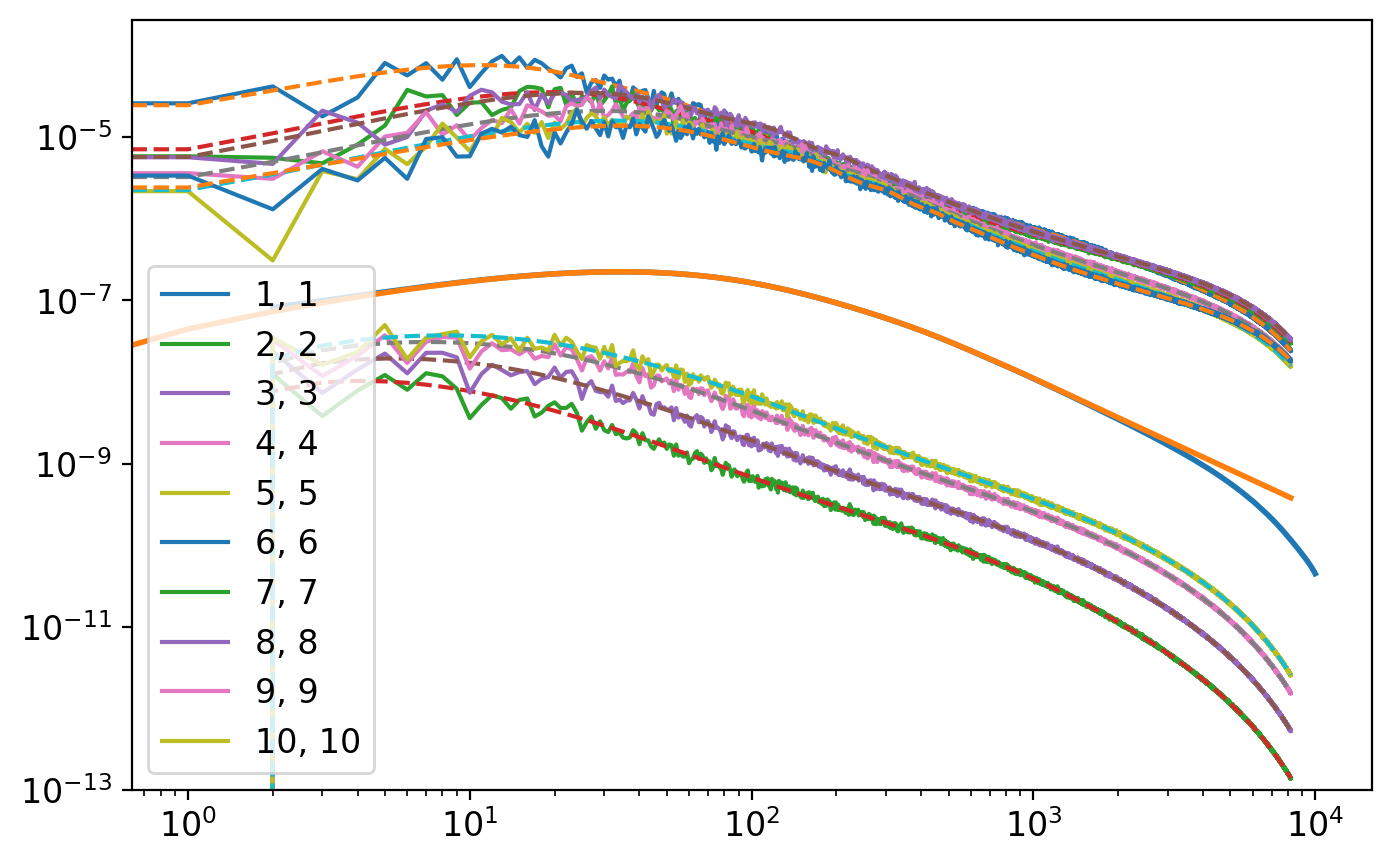

In [27]:
alms2 = hp.synalm(clsfields, new = True)
for i in range(1, len(alms2)+1):
    for j in range(i, i+1):
        #plt.loglog(hp.alm2cl(alms_curved[i], alms_curved[j]))
        plt.loglog(hp.alm2cl(alms2[i-1], alms2[j-1]), label = f"{i}, {j}")
        if i == 0:
            plt.plot(get_AB(fixed_index, fixed_index), ls = "--")
        else:
            plt.plot(get_AB(i-1, j-1), ls = "--")

act_data = np.loadtxt(pathlib.Path("cosmo2017_10K_acc3_lenspotentialCls.dat"))
ls = act_data[:, 0]
clkk = act_data[:, 5]*np.pi/2

plt.plot(ls, clkk, lw = 2)
plt.plot(get_AB(fixed_index, fixed_index), lw = 2)

#plt.plot(hp.alm2cl(klm), alpha = 0.5)

plt.ylim(1e-13)

plt.legend()

In [143]:
cppofficial = np.loadtxt("cosmo2017_10K_acc3_lenspotentialCls.dat").T[5]
cppofficial = np.concatenate([np.zeros(2), cppofficial])
ls = np.arange(cppofficial.size)
factorA = (ls*(ls + 1))**2/(2*np.pi)
factorB = (ls*(ls + 1)/(2))**2.
factor = factorB/factorA
clkkofficial = cppofficial*factor
clkkofficial[0] = 0

Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)
clkk_official = clkkofficial[:Getter(fixed_index, fixed_index).size]

/tmp/ipykernel_1554155/1518835701.py:6: RuntimeWarning: invalid value encountered in true_divide
  factor = factorB/factorA


/tmp/ipykernel_1554155/285419350.py:1: RuntimeWarning: invalid value encountered in true_divide
  discrepancy = np.sqrt(clkk_official/Getter(fixed_index, fixed_index))


Text(0.5, 1.0, 'ACT lensing potential power spectrum discrepancy, ACT 2017 lens file vs Limber CCL integration')

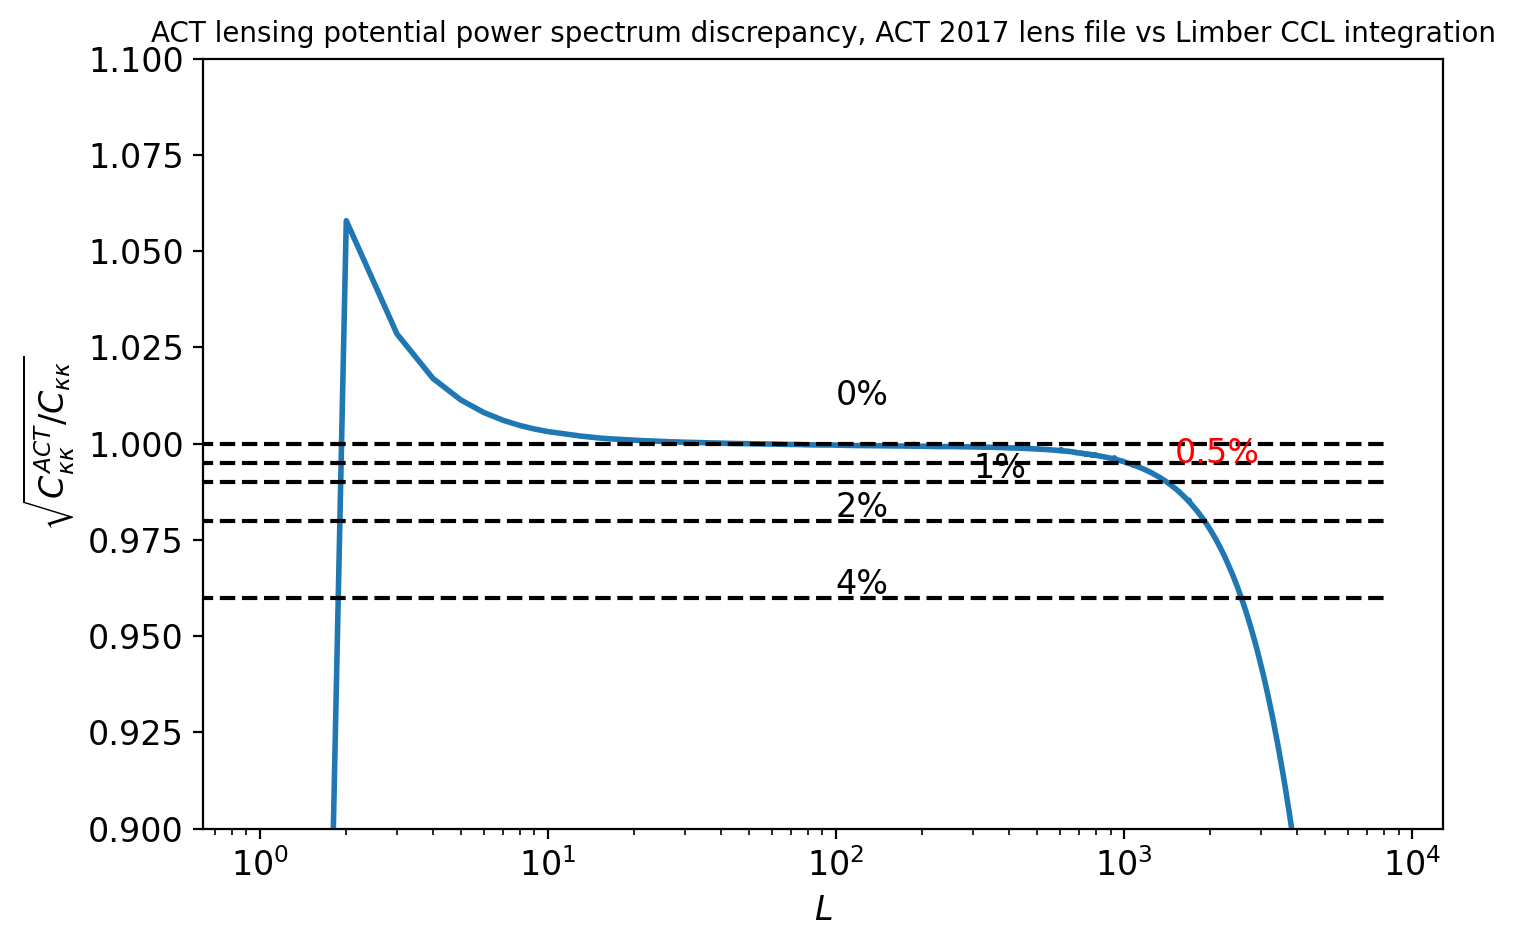

In [160]:
discrepancy = np.sqrt(clkk_official/Getter(fixed_index, fixed_index))
plt.plot(discrepancy, lw = 2)
plt.ylabel(r'$\sqrt{C_{\kappa\kappa}^{ACT}/C_{\kappa\kappa}}$')
plt.xlabel(r'$L$')
plt.hlines(1, 0, discrepancy.size, color = 'k', ls = '--')
plt.hlines(0.98, 0, discrepancy.size, color = 'k', ls = '--')
plt.hlines(0.96, 0, discrepancy.size, color = 'k', ls = '--')
plt.hlines(0.99, 0, discrepancy.size, color = 'k', ls = '--')
plt.hlines(0.995, 0, discrepancy.size, color = 'k', ls = '--')

plt.text(100, 1.01, '0%')
plt.text(1500, 0.995, '0.5%', color = 'r')
plt.text(300, 0.991, '1%')
plt.text(100, 0.981, '2%')
plt.text(100, 0.961, '4%')

plt.ylim(0.9, 1.1)
plt.xscale('log')

plt.title("ACT lensing potential power spectrum discrepancy, ACT 2017 lens file vs Limber CCL integration", fontsize = 10)

In [9]:
#now, I want the yy from kk official, and yy from kk CCL
from fieldgen import trfutils, logutils as lgu

lambda_k = lambda_cmbl

alpha_matrix = np.array([[lambda_k**2.]])

ls = np.arange(Getter(fixed_index, fixed_index).size)
filter = lgu.suppress(ls, 9000, 30)

#cltol = 1e-6

cls_ = np.array([[clkk_official*filter]])
clyy_official = trfutils.cls_to_gcls(cls_, alpha_matrix)[0, 0]

cls_ = np.array([[Getter(fixed_index, fixed_index)]]) #Getter has the filter already
clyy = trfutils.cls_to_gcls(cls_, alpha_matrix)[0, 0]

#cls = np.array([[Getter(fixed_index, fixed_index)]]) #Getter has the filter already
#clyy_ = trfutils.cls_to_gcls(cls, alpha_matrix, cltol = 1e-10, gltol = 1e-10)[0, 0]

Calculating 0 0


/home/users/d/darwish/.conda/envs/xcorr/lib/python3.10/site-packages/gaussiancl.py:79: RuntimeWarning: divide by zero encountered in true_divide
  q = np.divide(dx, x, where=(dx != 0), out=np.zeros_like(dx))


Time 5.556644916534424
Done 0 0
Calculating 0 0
Time 5.545690059661865
Done 0 0
Calculating 0 0
Time 44.07013010978699
Done 0 0


In [66]:
cls.shape

(11, 11, 8192)

In [126]:
indxs = [0, 7, 8, 9, 10]
indxs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
NN = len(indxs)

clsG_new = np.zeros((len(indxs), len(indxs), 8192))

for i, id in enumerate(indxs):
    for j, jd in enumerate(indxs):
        clsG_new[i, j] = cls[id, jd]

In [127]:
lambdas_gcgc = np.array([1.089,1.106,1.046,1.252,1.177,1.177])

lambdas_gcgc = np.array([0.8643903597477973, 1.0473103985771925, 1.0861042389666111, 1.137767329477515, 1.357844032114365, 1.3010215231771014])
#lambdas_gcgc = np.array([1.089,1.106,1.047,1.13777,1.35784, 1.30102])

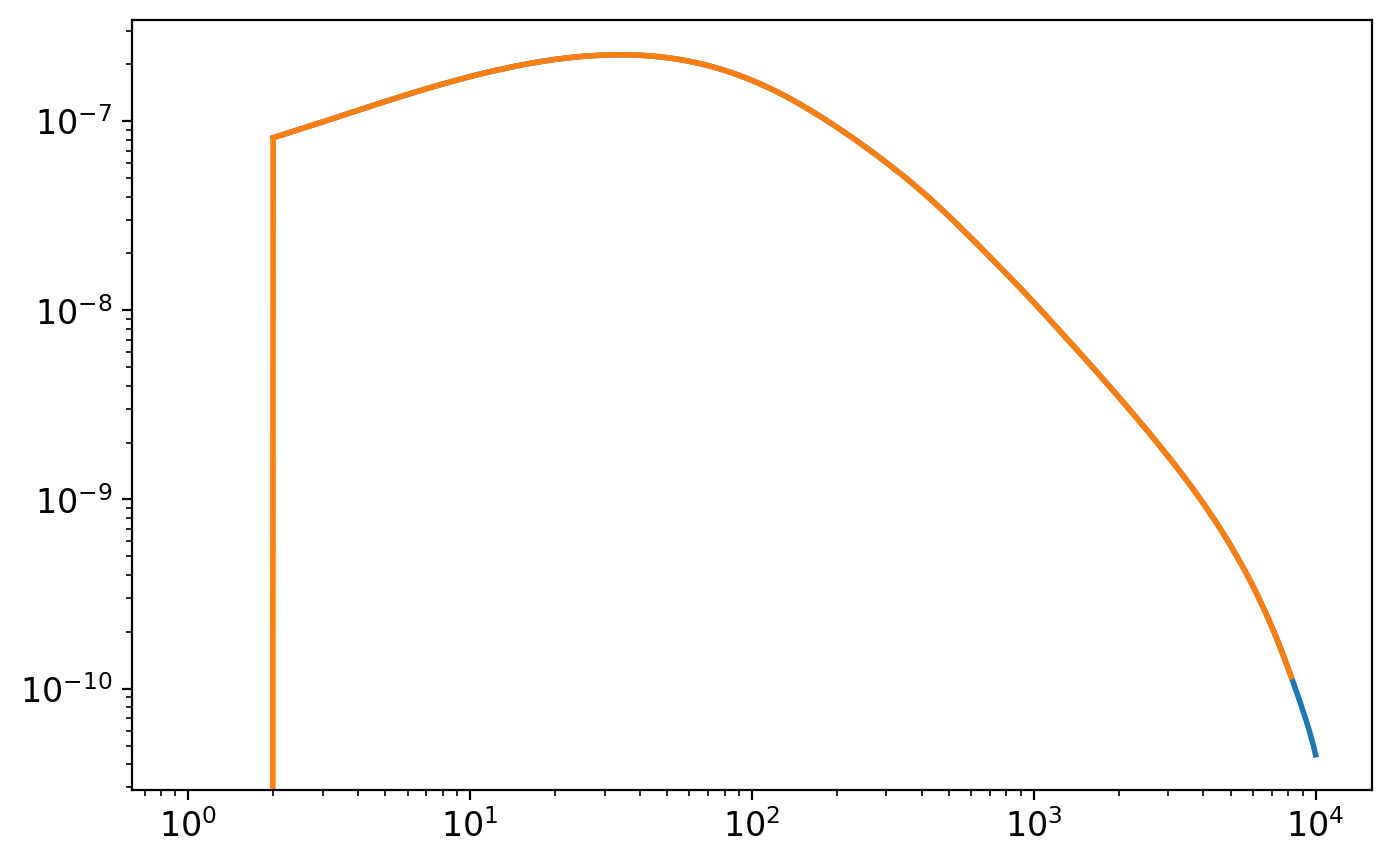

In [134]:
plt.plot(ls, clkk, lw = 2)
plt.loglog(get_AB(fixed_index, fixed_index), lw = 2)

In [135]:
lambda_k

array([3])

In [138]:
from fieldgen import utils

mean = 2.0133666795033844e-10
#lambdas_gsgs_ = np.array([0.00453, 0.00885, 0.022, 0.034])
lambdas_gsgs_ = np.array([0.00453, 0.01, 0.022, 0.034])
lambdas_ = np.concatenate([[200], lambdas_gcgc, lambdas_gsgs_])

lambdas_ = lambdas_[indxs]

alphas = lambdas_+mean
alpha_matrix = np.outer(alphas, alphas)
cltol = 1e-5
clsg_3 = trfutils.cls_to_gcls(clsG_new, alpha_matrix, cltol = cltol, gltol = cltol)

from pixell import curvedsky
almsC_3 = curvedsky.rand_alm(clsg_3)

Calculating 0 0


/home/users/d/darwish/.conda/envs/xcorr/lib/python3.10/site-packages/gaussiancl.py:79: RuntimeWarning: divide by zero encountered in true_divide
  q = np.divide(dx, x, where=(dx != 0), out=np.zeros_like(dx))


Time 37.524388790130615
Done 0 0
Calculating 0 1
Time 5.019496440887451
Done 0 1
Calculating 0 2
Time 5.0729615688323975
Done 0 2
Calculating 0 3
Time 5.121174097061157
Done 0 3
Calculating 0 4
Time 5.070341348648071
Done 0 4
Calculating 0 5
Time 5.114760398864746
Done 0 5
Calculating 0 6
Time 5.149273872375488
Done 0 6
Calculating 0 7
Time 5.084154367446899
Done 0 7
Calculating 0 8
Time 5.088839054107666
Done 0 8
Calculating 0 9
Time 5.039453029632568
Done 0 9
Calculating 0 10
Time 5.197026968002319
Done 0 10
Calculating 1 1
Time 7.010980844497681
Done 1 1
Calculating 1 2
Time 5.244950771331787
Done 1 2
Calculating 1 3
Time 3.122831344604492
Done 1 3
Calculating 1 4
Time 3.1457061767578125
Done 1 4
Calculating 1 5
Time 3.1248645782470703
Done 1 5
Calculating 1 6
Time 3.0832908153533936
Done 1 6
Calculating 1 7
Time 7.036735534667969
Done 1 7
Calculating 1 8
Time 7.121014595031738
Done 1 8
Calculating 1 9
Time 7.1864564418792725
Done 1 9
Calculating 1 10
Time 7.256943941116333
Done 1 1

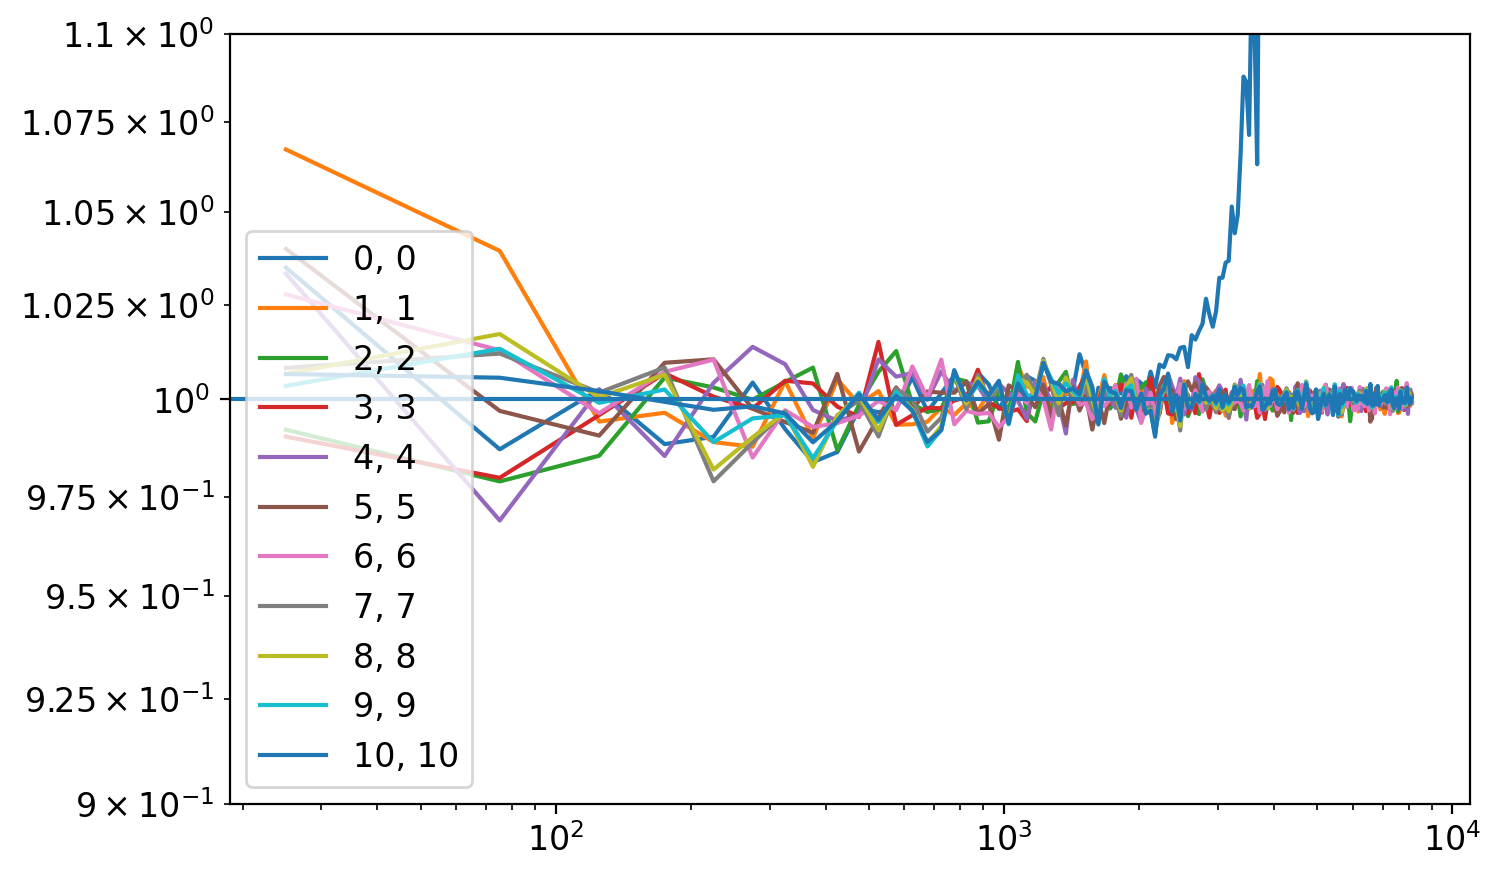

In [139]:
bin_edges = np.arange(0, 8193, 50)

for i, alm in enumerate(almsC_3):
    #if i != 0:
    #    continue
    j = i

    centst, dt = fgutils.simple_binning(clsg_3[i, j], bin_edges)
    cents, a = fgutils.simple_binning(hp.alm2cl(alm), bin_edges)
    plt.loglog(cents, a/dt, label = f"{i}, {j}")

plt.ylim(0.9, 1.1)
plt.legend()

plt.hlines(1, 0, 8192)

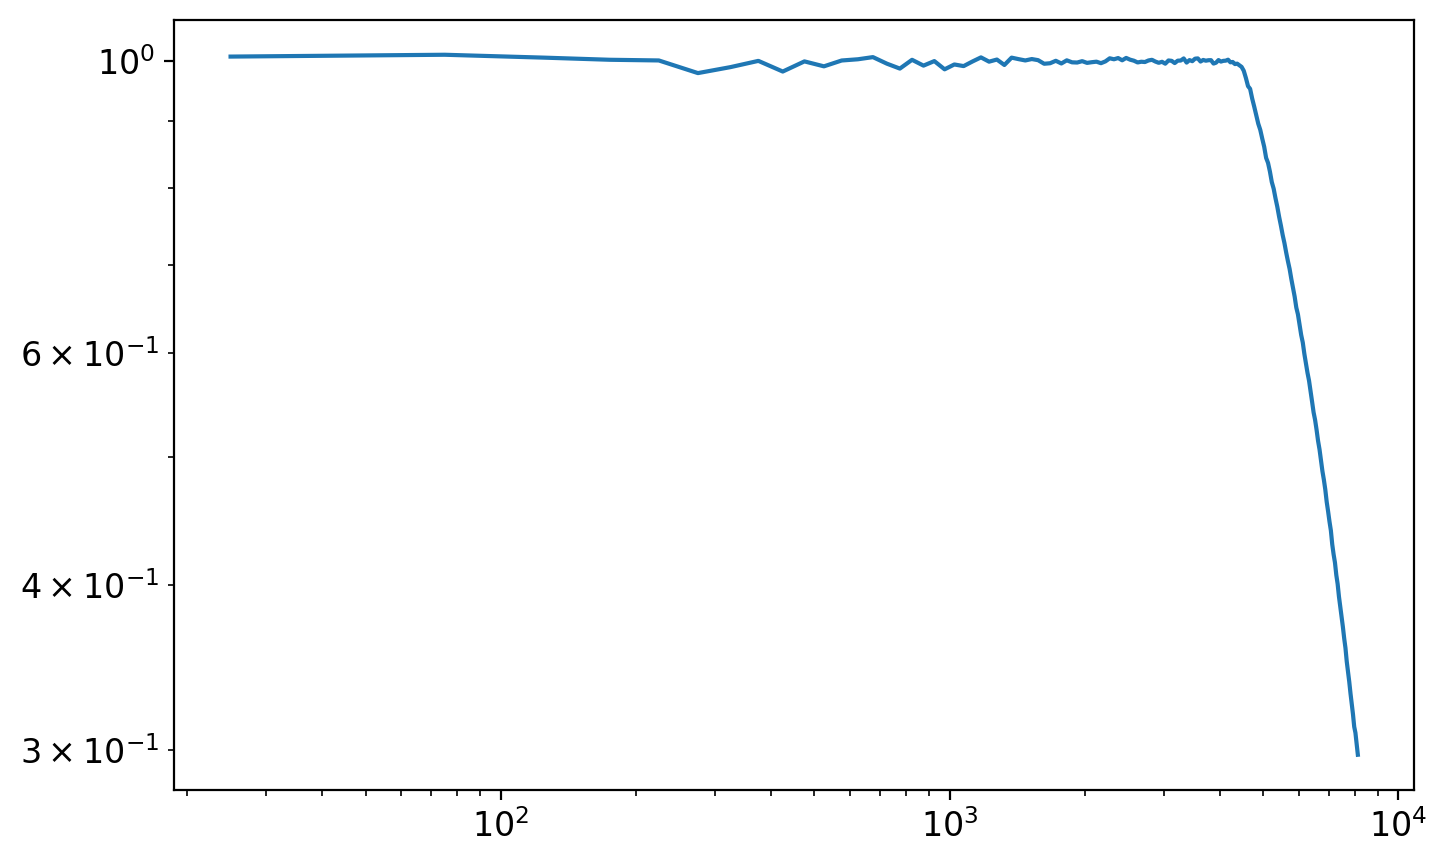

In [132]:
i = 0
j = 0
centst, dt = fgutils.simple_binning(clsg_3[i, j], bin_edges)
cents, a = fgutils.simple_binning(hp.alm2cl(almsC_3[0]), bin_edges)
plt.loglog(cents, dt/a, label = f"{i}, {j}")

In [ ]:
NN = Nfields-1
clsG_new = np.zeros((NN, NN, 8192))


indxs = np.arange(NN-1)

indxs = [6, 7, 8, 9]
clsG_new = np.zeros((len(indxs), len(indxs), 8192))

for i, id in enumerate(indxs):
    for j, jd in enumerate(indxs):
        clsG_new[i, j] = new_getter(id, jd)
        #clsG_new[i+1, j+1] = new_getter(i, j)
    #clsG_new[0, i+1] = new_getter(fixed_index, i)
    #clsG_new[i+1, 0] = clsG_new[0, i+1]


#clsG_new[0, 0] = new_getter(fixed_index, fixed_index)
almsC_new = curvedsky.rand_alm(clsG_new)

In [23]:
Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)
lsup, supindex = 9000, 30
Getter.cls = lgu.process_cl(Getter.cls, lsup = lsup, supindex = supindex)

mean_kappa = 0.

LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields))

Calculating 0 0
Time 5.323535442352295
Done 0 0
Calculating 0 1
Time 5.199756145477295
Done 0 1
Calculating 0 2
Time 5.1219401359558105
Done 0 2
Calculating 0 3
Time 5.0823585987091064
Done 0 3
Calculating 0 4
Time 5.079306125640869
Done 0 4
Calculating 0 5
Time 5.107257604598999
Done 0 5
Calculating 0 6
Time 5.113234519958496
Done 0 6
Calculating 0 7
Time 5.182636260986328
Done 0 7
Calculating 0 8
Time 5.129360198974609
Done 0 8
Calculating 0 9
Time 5.144900560379028
Done 0 9
Calculating 0 10
Time 5.097446441650391
Done 0 10
Calculating 1 1
Time 5.116132020950317
Done 1 1
Calculating 1 2
Time 5.252075433731079
Done 1 2
Calculating 1 3
Time 3.1007065773010254
Done 1 3
Calculating 1 4
Time 3.0918047428131104
Done 1 4
Calculating 1 5
Time 3.130692720413208
Done 1 5
Calculating 1 6
Time 3.1399168968200684
Done 1 6
Calculating 1 7
Time 7.226478338241577
Done 1 7
Calculating 1 8
Time 7.1352949142456055
Done 1 8
Calculating 1 9
Time 7.172224998474121
Done 1 9
Calculating 1 10
Time 7.18472862

/home/users/d/darwish/fieldgen/fieldgen/conditionedsims.py:151: RuntimeWarning: invalid value encountered in sqrt
  clsfieldscross = utils.divide(clsfieldscross, np.sqrt(kk)) #clsfieldscross/np.sqrt(kk)


In [131]:
cls_copy = cls.copy()
cls_copy[0, 0] = clkk_official
Getter_copy = fgutils.SpectraGetter(cls_copy, fixed_index)
lsup, supindex = 9000, 30
Getter_copy.cls = lgu.process_cl(Getter_copy.cls, lsup = lsup, supindex = supindex)
LC_official = lognormal.LognormalConditionedSims(Nfields-1, Getter_copy, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields))

Calculating 0 0
Time 5.041107416152954
Done 0 0
Calculating 0 1
Time 5.000683784484863
Done 0 1
Calculating 0 2
Time 4.997254371643066
Done 0 2
Calculating 0 3
Time 5.015038967132568
Done 0 3
Calculating 0 4
Time 5.001034736633301
Done 0 4
Calculating 0 5
Time 5.008523941040039
Done 0 5
Calculating 0 6
Time 5.027934551239014
Done 0 6
Calculating 0 7
Time 5.016602516174316
Done 0 7
Calculating 0 8
Time 5.01310396194458
Done 0 8
Calculating 0 9
Time 5.006033182144165
Done 0 9
Calculating 0 10
Time 5.021570920944214
Done 0 10
Calculating 1 1
Time 5.028557300567627
Done 1 1
Calculating 1 2
Time 5.019972324371338
Done 1 2
Calculating 1 3
Time 3.076796531677246
Done 1 3
Calculating 1 4
Time 3.0468130111694336
Done 1 4
Calculating 1 5
Time 3.046603202819824
Done 1 5
Calculating 1 6
Time 3.055436134338379
Done 1 6
Calculating 1 7
Time 6.971902847290039
Done 1 7
Calculating 1 8
Time 6.962716341018677
Done 1 8
Calculating 1 9
Time 6.969364643096924
Done 1 9
Calculating 1 10
Time 6.94739699363708

/home/users/d/darwish/fieldgen/fieldgen/conditionedsims.py:151: RuntimeWarning: invalid value encountered in sqrt
  clsfieldscross = utils.divide(clsfieldscross, np.sqrt(kk)) #clsfieldscross/np.sqrt(kk)


In [32]:
from fieldgen import utils

lambdas_gsgs_ = np.array([0.00453, 0.01, 0.022, 0.034])
lambdas_ = np.concatenate([lambda_k, lambdas_gcgc, lambdas_gsgs_])

alphas = lambdas_
alpha_matrix = np.outer(alphas, alphas)
cltol = 1e-5
clsg = trfutils.cls_to_gcls(cls, alpha_matrix, cltol = cltol, gltol = cltol)
#new_getter = utils.SpectraGetter(clsg, LC.get_AB.realized_field_index)

Calculating 0 0


/home/users/d/darwish/.conda/envs/xcorr/lib/python3.10/site-packages/gaussiancl.py:79: RuntimeWarning: divide by zero encountered in true_divide
  q = np.divide(dx, x, where=(dx != 0), out=np.zeros_like(dx))


Time 5.316824197769165
Done 0 0
Calculating 0 1
Time 5.319726228713989
Done 0 1
Calculating 0 2
Time 5.258711814880371
Done 0 2
Calculating 0 3
Time 5.234687089920044
Done 0 3
Calculating 0 4
Time 5.304536581039429
Done 0 4
Calculating 0 5
Time 5.2996766567230225
Done 0 5
Calculating 0 6
Time 5.258280992507935
Done 0 6
Calculating 0 7
Time 5.248316526412964
Done 0 7
Calculating 0 8
Time 5.285053968429565
Done 0 8
Calculating 0 9
Time 5.275689363479614
Done 0 9
Calculating 0 10
Time 5.215826034545898
Done 0 10
Calculating 1 1
Time 5.264710187911987
Done 1 1
Calculating 1 2
Time 5.2938549518585205
Done 1 2
Calculating 1 3
Time 3.236142158508301
Done 1 3
Calculating 1 4
Time 3.2468745708465576
Done 1 4
Calculating 1 5
Time 3.263449192047119
Done 1 5
Calculating 1 6
Time 3.2183337211608887
Done 1 6
Calculating 1 7
Time 7.356440544128418
Done 1 7
Calculating 1 8
Time 7.316471338272095
Done 1 8
Calculating 1 9
Time 7.4389684200286865
Done 1 9
Calculating 1 10
Time 5.321359634399414
Done 1 10

In [26]:
from pixell import curvedsky

clsG = np.zeros((Nfields, Nfields, 8192))

for i in range(Nfields-1):
    for j in range(Nfields-1):
        clsG[i+1, j+1] = LC.get_AB_gaussian(i, j)
    clsG[0, i+1] = LC.get_AB_gaussian(fixed_index, i)
    clsG[i+1, 0] = clsG[0, i+1]
clsG[0, 0] = LC.get_AB_gaussian(fixed_index, fixed_index)

almsC = curvedsky.rand_alm(clsG)

In [141]:
clsG_official = np.zeros((Nfields, Nfields, 8192))

for i in range(Nfields-1):
    for j in range(Nfields-1):
        clsG_official[i+1, j+1] = LC_official.get_AB_gaussian(i, j)
    clsG_official[0, i+1] = LC_official.get_AB_gaussian(fixed_index, i)
    clsG_official[i+1, 0] = clsG_official[0, i+1]

clsG_official[0, 0] = LC_official.get_AB_gaussian(fixed_index, fixed_index)

almsC_official = curvedsky.rand_alm(clsG_official)

In [33]:
almsC_new = curvedsky.rand_alm(clsg)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


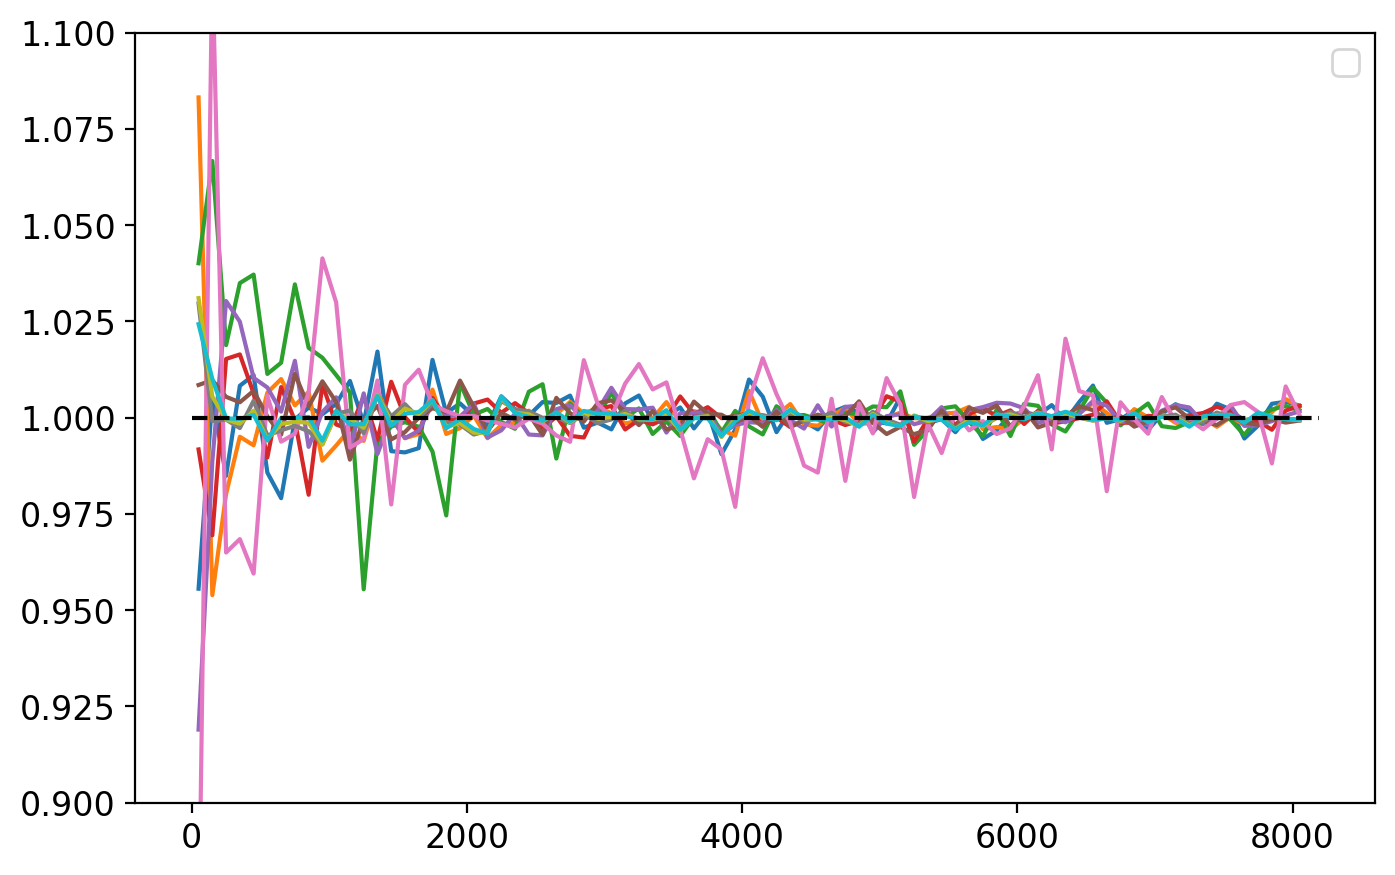

In [36]:
bin_edges = np.arange(0, 8193, 100)

for i, id in enumerate(almsC_new[1:]):

    j = i+1
    #theory = clsG[i, j]
    #centst, dt = fgutils.simple_binning(theory, bin_edges)
    #cents, a = fgutils.simple_binning(hp.alm2cl(almsC[i], almsC[j]), bin_edges)
    #plt.plot(cents, a/dt)

    #theory = clsG_official[i, j]
    #centst, dt = fgutils.simple_binning(theory, bin_edges)
    #cents, a = fgutils.simple_binning(hp.alm2cl(almsC_official[i], almsC_official[j]), bin_edges)
    #plt.plot(cents, a/dt)

    theory = clsg[i, j]
    centst, dt = fgutils.simple_binning(theory, bin_edges)
    cents, a = fgutils.simple_binning(hp.alm2cl(almsC_new[i], almsC_new[j]), bin_edges)
    plt.plot(cents, a/dt)

plt.legend()
plt.ylim(0.9, 1.1)

plt.hlines(1, 0, 8192, ls = "--", color = "black")

In [52]:
(clsG_new[i, j]/clsG[i, j]).max()

1.0000003202188597

(0.9, 1.1)

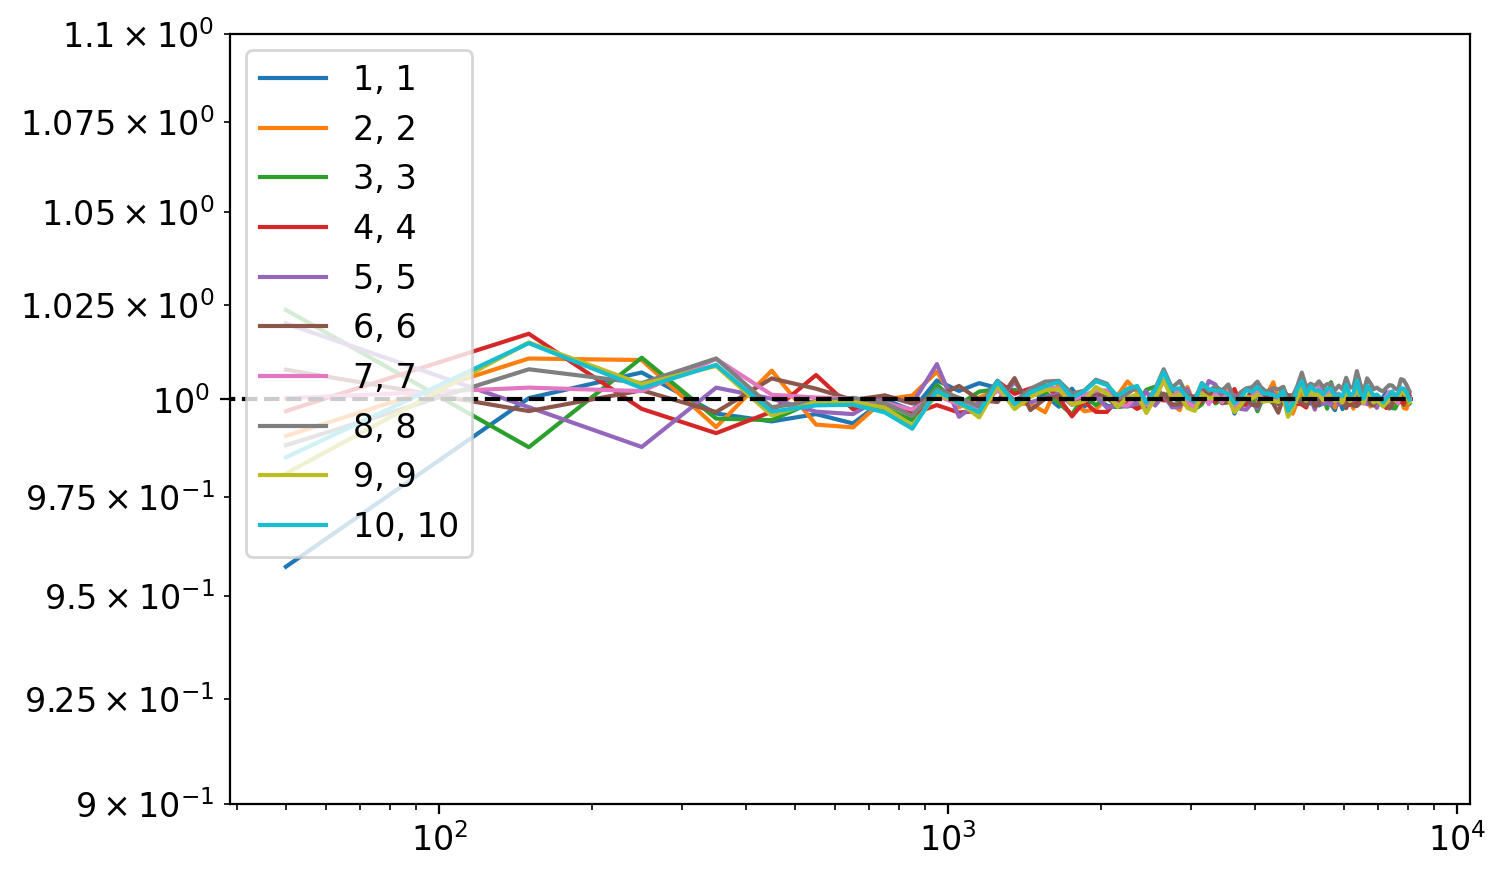

In [122]:

for i in range(1, len(lambdas)):
    for j in range(i, i+1):#len(lambdas)-1):
        #print(i, j)
        theory = clsG_new[i, j]
        centst, dt = fgutils.simple_binning(theory, bin_edges)
        cents, a = fgutils.simple_binning(hp.alm2cl(almsC_new[i], almsC_new[j]), bin_edges)
        plt.loglog(cents, a/dt, label = f"{i}, {j}")
        #plt.loglog(cents, dt, ls = "--")
plt.hlines(1, 0, 8192, ls = "--", color = "black")
plt.legend()
plt.ylim(0.9, 1.1)

In [12]:
cppofficial = np.loadtxt("cosmo2017_10K_acc3_lenspotentialCls.dat").T[5]
cppofficial = np.concatenate([np.zeros(2), cppofficial])
ls = np.arange(cppofficial.size)
factorA = (ls*(ls + 1))**2/(2*np.pi)
factorB = (ls*(ls + 1)/(2))**2.
factor = factorB/factorA
clkkofficial = cppofficial*factor
clkkofficial[0] = 0

clkkofficial.size

/tmp/ipykernel_547301/937003470.py:6: RuntimeWarning: invalid value encountered in true_divide
  factor = factorB/factorA


10001

In [73]:
nside_gen = 4096
#nside_gen = 2048

direc_phi = pathlib.Path("/home/users/d/darwish/scratch/signal_sims/")
name_phi = f"fullskyPhi_alm_{seed:05}.fits"

#for some reaons pxlensing giving weird results, so do by hand
philm = hp.read_alm(direc_phi/name_phi).astype(np.complex128)
lmax = hp.Alm.getlmax(philm.size)
lphi = np.arange(lmax + 1)
factor = lphi*(lphi + 1)/(2)
klm = hp.almxfl(philm, factor)#[:8192]
#kappa = shts.alm2map(klm.copy().astype(np.complex128), nside = nside_gen)

In [74]:
def alm_copy_full(alm:np.ndarray, mmaxin:int or None, lmaxout:int, mmaxout:int):
    """Copies the healpy alm array, with the option to change its lmax

        Parameters
        ----------
        alm :ndarray
            healpy alm arrays to copy.
        mmaxin: int or None
            mmax parameter of input array (can be set to None or negative for default)
        lmaxout : int
            new alm lmax
        mmaxout: int
            new alm mmax


    """
    alms = np.atleast_2d(alm)
    ret = []
    for alm in alms:
        lmaxin = hp.Alm.getlmax(alm.size, mmaxin)
        if mmaxin is None or mmaxin < 0: mmaxin = lmaxin
        if (lmaxin == lmaxout) and (mmaxin == mmaxout):
            ret.append(np.copy(alm))
        else:
            _ret = np.zeros(hp.Alm.getsize(lmaxout, mmaxout), dtype=alm.dtype)
            lmax_min = min(lmaxout, lmaxin)
            for m in range(0, min(mmaxout, mmaxin) + 1):
                idx_in =  m * (2 * lmaxin + 1 - m) // 2 + m
                idx_out = m * (2 * lmaxout+ 1 - m) // 2 + m
                _ret[idx_out: idx_out + lmax_min + 1 - m] = alm[idx_in: idx_in + lmax_min + 1 - m]
            ret.append(_ret)
    ret = np.array(ret)
    if ret.shape[0] == 1:
        return ret[0]
    else:
        return ret


philm = hp.read_alm(direc_phi/name_phi).astype(np.complex128)
lmax = hp.Alm.getlmax(philm.size)
lphi = np.arange(lmax + 1)
factor = lphi*(lphi + 1)/(2)
klm = hp.almxfl(philm, factor)

kk_full = clkkofficial[:Getter(fixed_index, fixed_index).size]  #Getter(fixed_index, fixed_index).copy()
np.random.seed(seed)
klm_other = hp.synalm(kk_full)
filter = np.ones(kk_full.size)
filter[:lmax+1] = 0
klm_other = hp.almxfl(klm_other, filter)
lmax_other = hp.Alm.getlmax(klm_other.size)

klm_full = alm_copy_full(klm, mmaxin = lmax, lmaxout = lmax_other, mmaxout = lmax_other)

klm_full += klm_other

kappa = shts.alm2map(klm_full.copy(), nside = nside_gen)


mean_kappa = logutils.get_mean_from_map(kappa) #note mean calc at nside_gen
mean_kappa

2.0133666795033844e-10

In [ ]:
# klm_full comes from ACT 2017 acc 3

In [75]:
spectra_dir = pathlib.Path("/home/users/d/darwish/ACTdr6xDESy3/actxdes/data/spectra_mnu_takahashiactln_fit/")
clkk_ccl = np.loadtxt(pathlib.Path(spectra_dir/"cl_kk.txt")).T[1]

#klm_full = hp.synalm(clkk, lmax = lmax)
#kappa = shts.alm2map(klm_full.copy(), nside = nside_gen)

#mean_kappa = logutils.get_mean_from_map(kappa) #note mean calc at nside_gen
#mean_kappa

In [79]:
clkk_official = clkkofficial[:Getter(fixed_index, fixed_index).size]

/tmp/ipykernel_260502/283229369.py:1: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(Getter(fixed_index, fixed_index)/clkk_official)
/tmp/ipykernel_260502/283229369.py:1: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(Getter(fixed_index, fixed_index)/clkk_official)


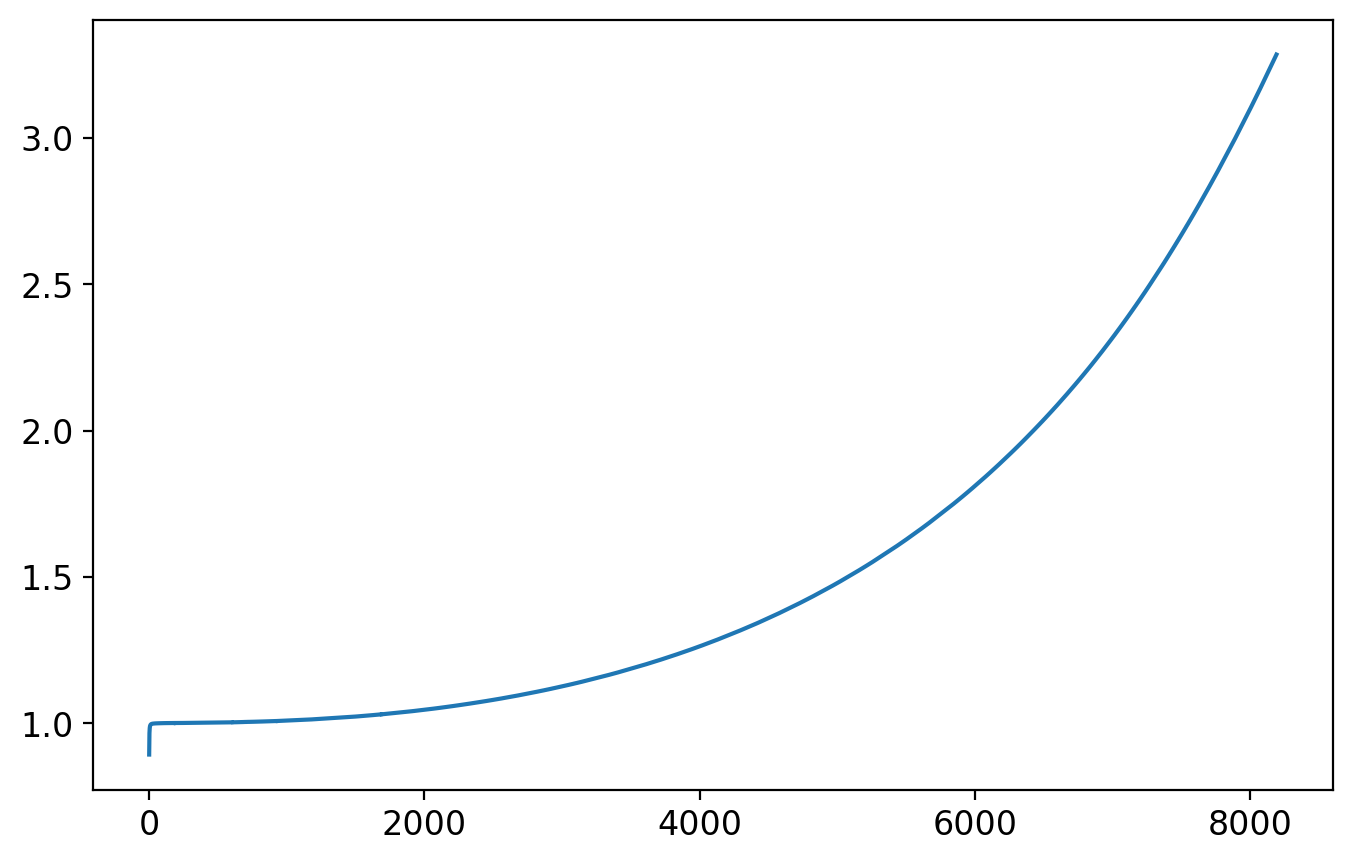

In [80]:
plt.plot(Getter(fixed_index, fixed_index)/clkk_official)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


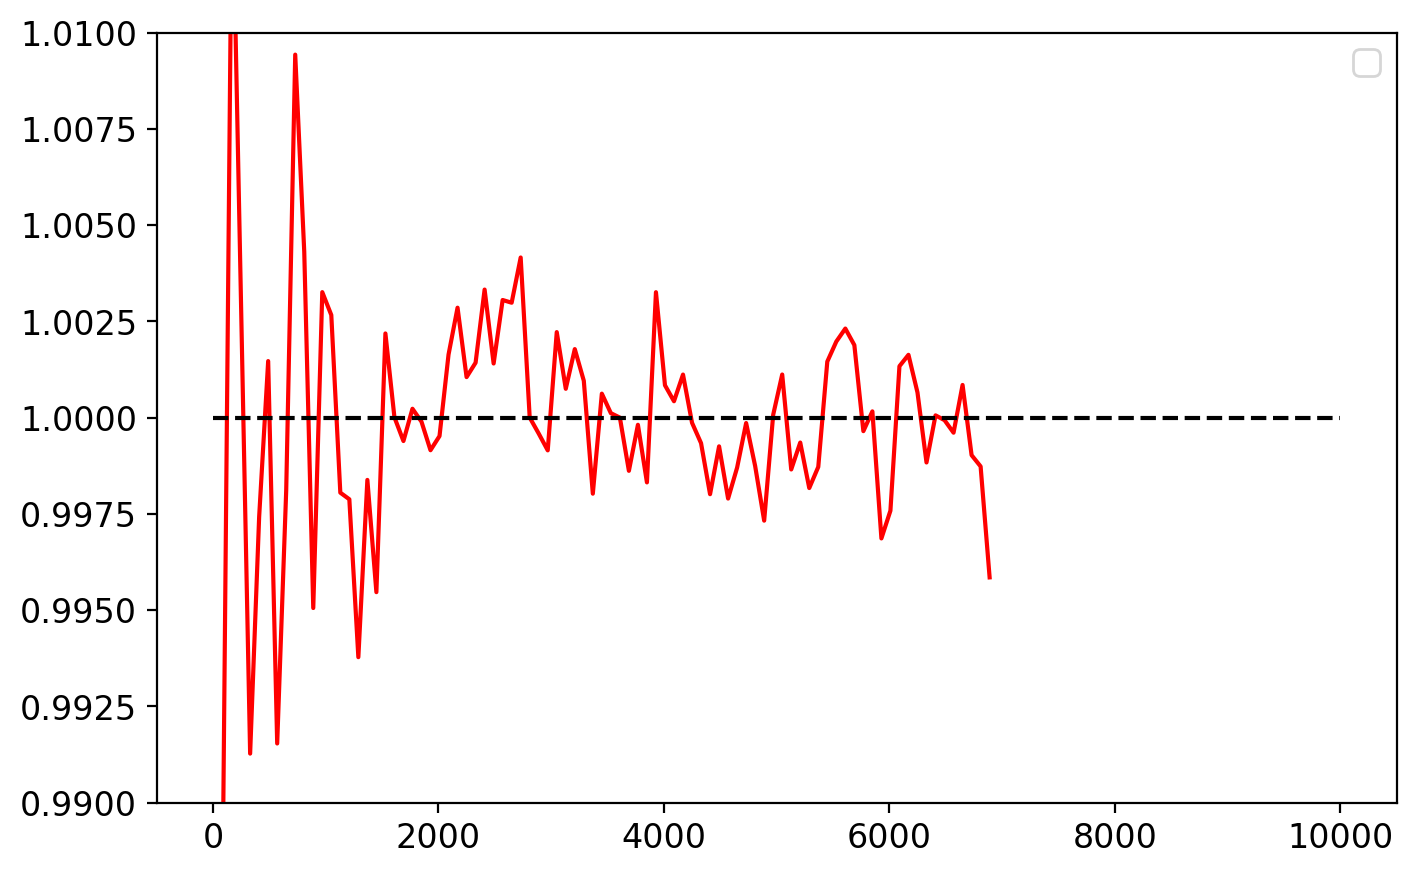

In [96]:
bin_edges = np.arange(50, 7000, 80)
theory = clkk_official #Getter(Nfields-1, Nfields-1)
centst, dt = fgutils.simple_binning(theory, bin_edges)

cents, a = fgutils.simple_binning(hp.alm2cl(klm_full), bin_edges)
plt.plot(cents, a/dt, color = "r")
plt.legend()
plt.ylim(0.99, 1.01)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")

## Now we are ready to generate fields

In [84]:
%reload_ext autoreload
%autoreload 2
from fieldgen import trfutils as trfu, logutils as lgu

In [85]:
Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)

lsup, supindex = 9000, 30
Getter.cls = lgu.process_cl(Getter.cls, lsup = lsup, supindex = supindex)

In [86]:
LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields))

Calculating 0 0


/home/users/d/darwish/.conda/envs/xcorr/lib/python3.10/site-packages/gaussiancl.py:79: RuntimeWarning: divide by zero encountered in true_divide
  q = np.divide(dx, x, where=(dx != 0), out=np.zeros_like(dx))


Time 5.304601430892944
Done 0 0
Calculating 0 1
Time 5.3153369426727295
Done 0 1
Calculating 0 2
Time 5.175851106643677
Done 0 2
Calculating 0 3
Time 5.1015095710754395
Done 0 3
Calculating 0 4
Time 5.130519151687622
Done 0 4
Calculating 0 5
Time 5.3290770053863525
Done 0 5
Calculating 0 6
Time 5.301692724227905
Done 0 6
Calculating 0 7
Time 5.138641357421875
Done 0 7
Calculating 0 8
Time 5.33617639541626
Done 0 8
Calculating 0 9
Time 5.3090434074401855
Done 0 9
Calculating 0 10
Time 5.253537893295288
Done 0 10
Calculating 1 1
Time 5.225345611572266
Done 1 1
Calculating 1 2
Time 5.210310220718384
Done 1 2
Calculating 1 3
Time 3.1463823318481445
Done 1 3
Calculating 1 4
Time 3.1067066192626953
Done 1 4
Calculating 1 5
Time 3.180931568145752
Done 1 5
Calculating 1 6
Time 3.152496576309204
Done 1 6
Calculating 1 7
Time 7.100896835327148
Done 1 7
Calculating 1 8
Time 7.109675645828247
Done 1 8
Calculating 1 9
Time 7.135986804962158
Done 1 9
Calculating 1 10
Time 7.2162370681762695
Done 1 1

/home/users/d/darwish/fieldgen/fieldgen/conditionedsims.py:151: RuntimeWarning: invalid value encountered in sqrt
  clsfieldscross = utils.divide(clsfieldscross, np.sqrt(kk)) #clsfieldscross/np.sqrt(kk)


In [87]:
"""for i in range(Nfields):
    for j in range(i, Nfields):
        plt.loglog(LC.get_AB_gaussian(i, j), label = f"{i}, {j}")
plt.legend()"""

'for i in range(Nfields):\n    for j in range(i, Nfields):\n        plt.loglog(LC.get_AB_gaussian(i, j), label = f"{i}, {j}")\nplt.legend()'

In [88]:
#ls = np.arange(10000)
#filter = lgu.suppress(ls, 9500, 30)
#nside_prova = nside_gen
#kappa = hp.alm2map(hp.almxfl(klm_full, filter), nside = nside_prova)

In [89]:
#lambdas = np.array([5, 1.089])

In [76]:
ls = np.arange(10000)
filter = lgu.suppress(ls, lsup, supindex)

filter = np.sqrt(lgu.suppress(ls, 9000, 30)) #because I am using the square of the filter for the spectra
nside_prova = nside_gen
kappa = shts.alm2map(hp.almxfl(klm_full, filter), nside = nside_prova)

In [77]:
hp.Alm.getlmax(klm_full.size)

8191

In [78]:
nside_prova

4096

In [132]:
lambda_k = lambdas[0]
print(lambda_k)
#y_kappa = np.log(kappa/lambda_k + 1)
y_kappa = np.log(kappa + lambda_k)
y_kappa_lm = shts.map2alm(y_kappa.copy(), lmax = 9000, nthreads = 32) #9000)
#y_kappa_lm_2 = shts.map2alm(y_kappa.copy(), lmax = 9999)

#y_kappa_lm_high_l = shts.map2alm(y_kappa.copy(), lmax = 9000, nthreads = 32) #9000)

3.0


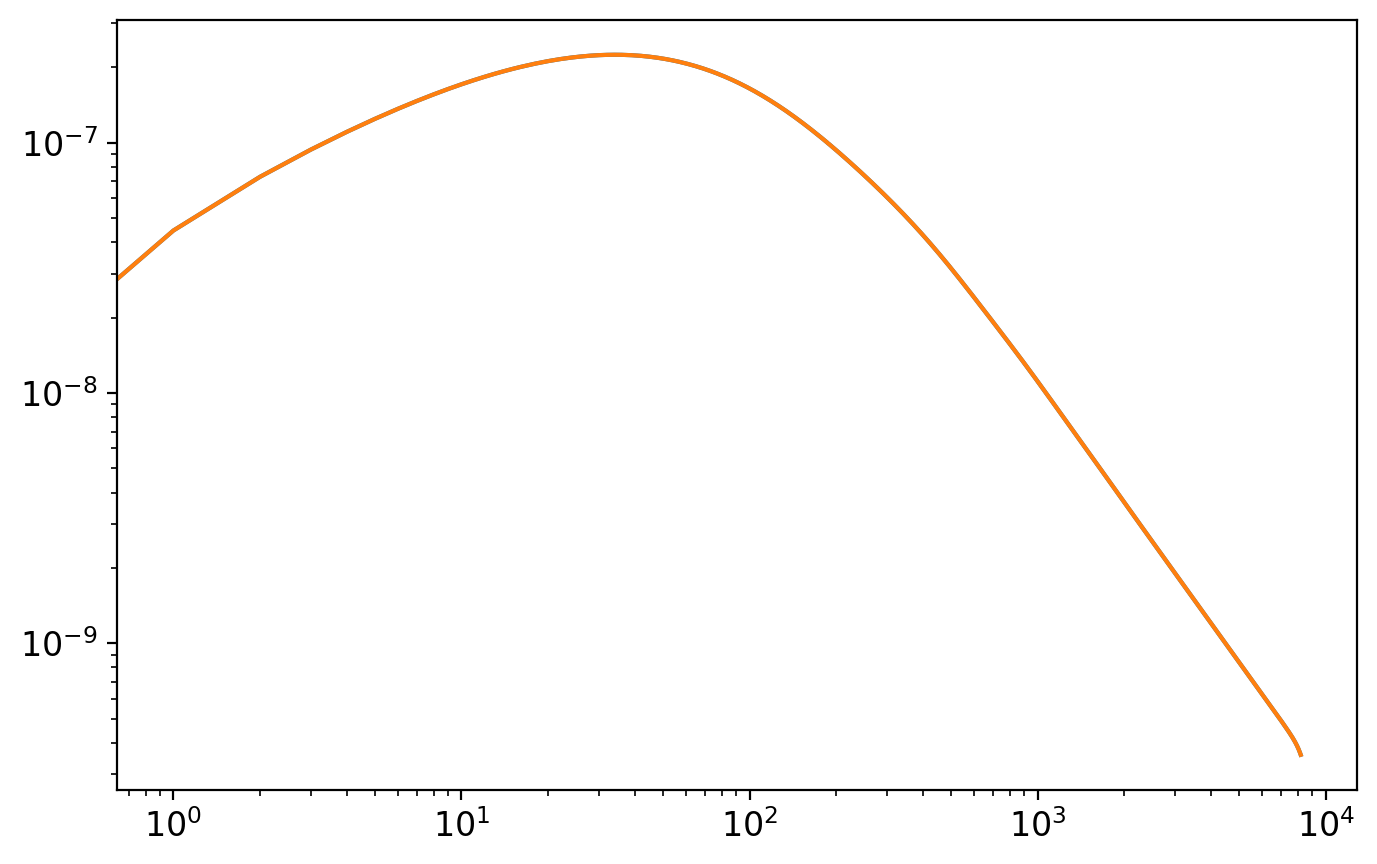

In [105]:
plt.loglog(Getter.cls[0, 0])
plt.plot(Getter(fixed_index, fixed_index))

In [133]:
#now, I want the yy from kk official, and yy from kk CCL
from fieldgen import trfutils
alpha_matrix = np.array([[lambda_k**2.]])

ls = np.arange(Getter(fixed_index, fixed_index).size)
filter = lgu.suppress(ls, 9000, 30)

cls = np.array([[clkk_official*filter]])
clyy_official = trfutils.cls_to_gcls(cls, alpha_matrix)[0, 0]

cls = np.array([[Getter(fixed_index, fixed_index)]]) #Getter has the filter already
clyy = trfutils.cls_to_gcls(cls, alpha_matrix)[0, 0]

Calculating 0 0
Time 5.050715208053589
Done 0 0
Calculating 0 0
Time 5.039831876754761
Done 0 0


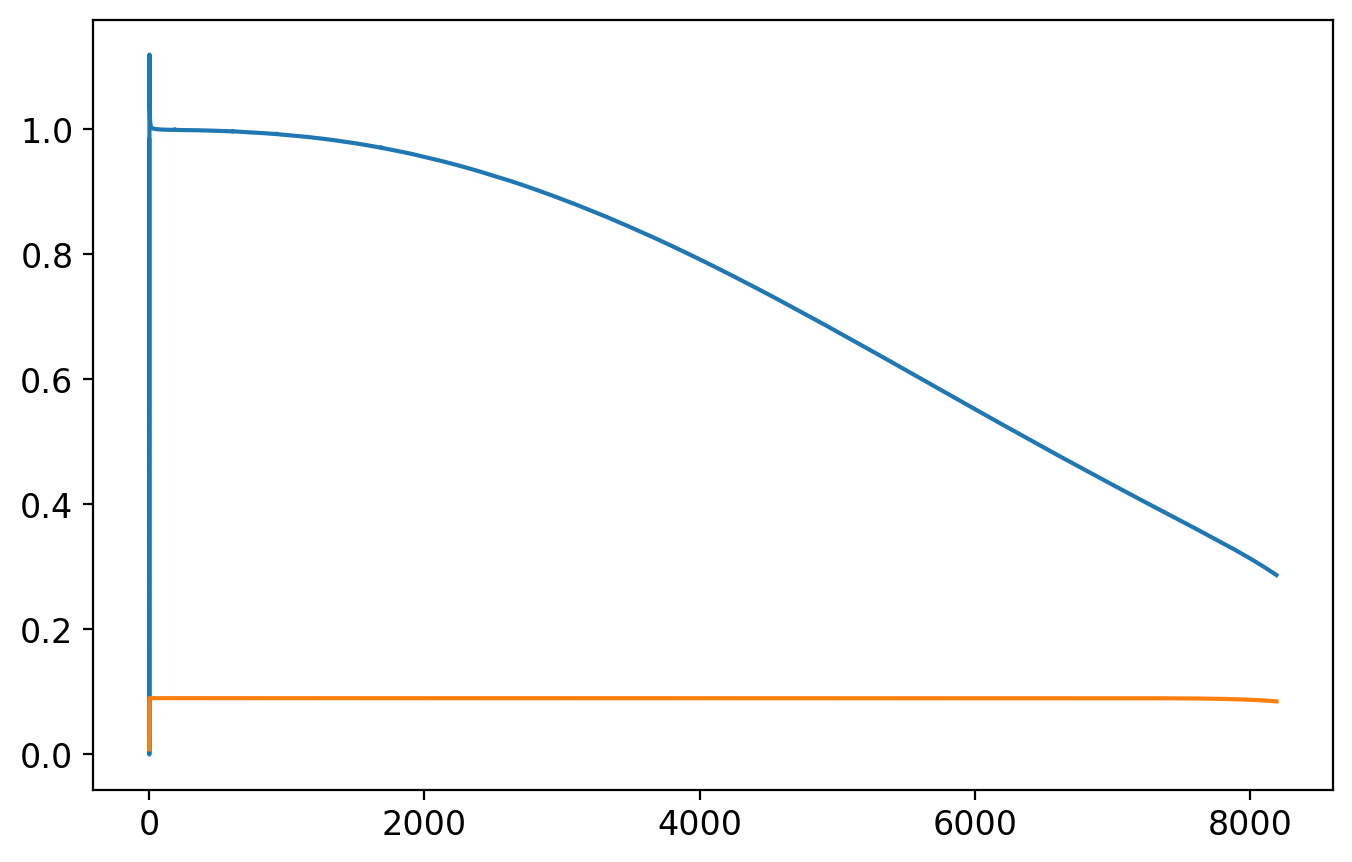

In [134]:
plt.plot(clyy_official/clyy)
plt.plot(LC.get_AB_gaussian(Nfields-1, Nfields-1)/clyy)

In [135]:
#LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields))
theory = clyy_official #LC.get_AB_gaussian(Nfields-1, Nfields-1)

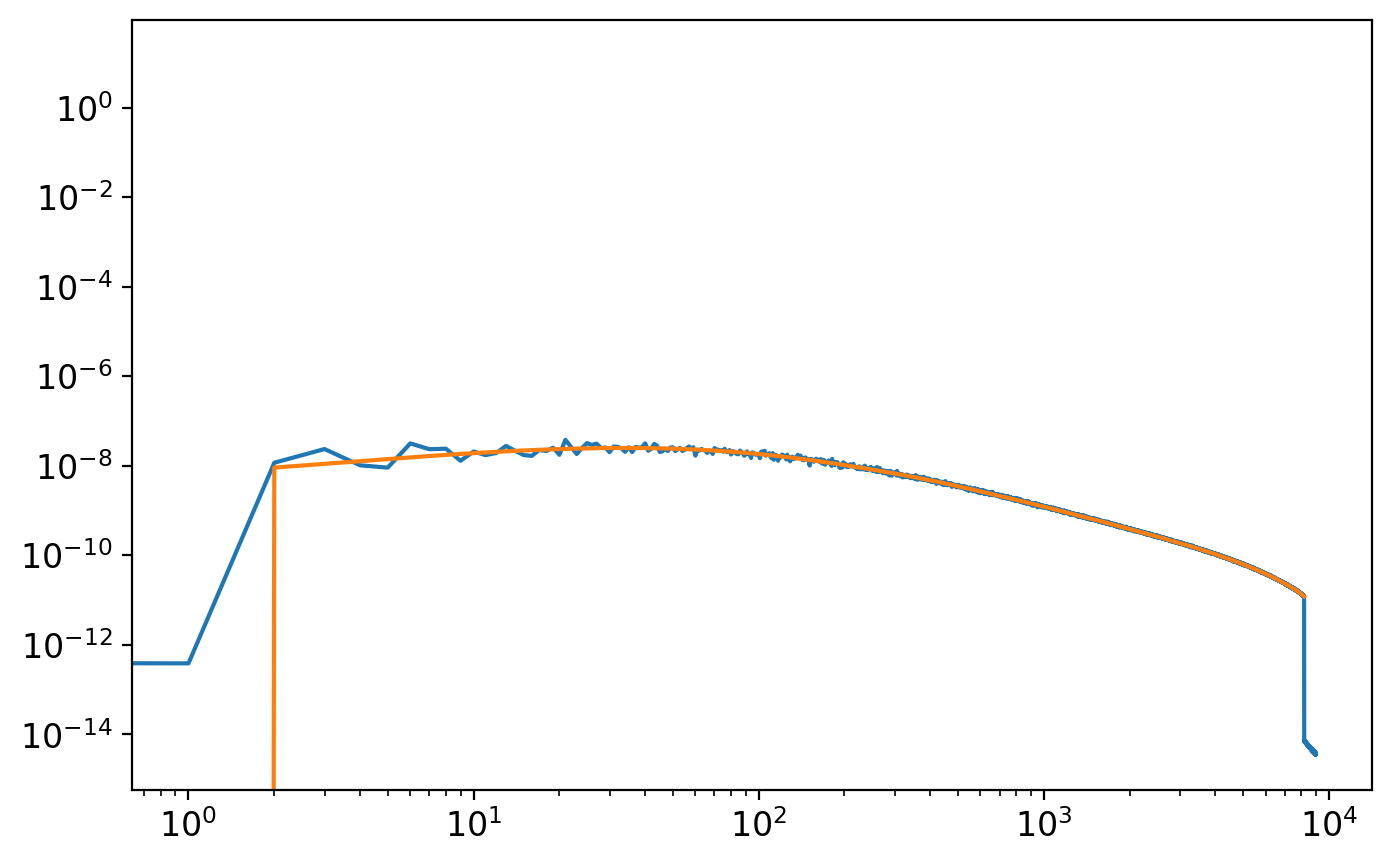

In [136]:
plt.loglog(hp.alm2cl(y_kappa_lm), label = "y_kappa_lm")
plt.plot(theory, label = "theory")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


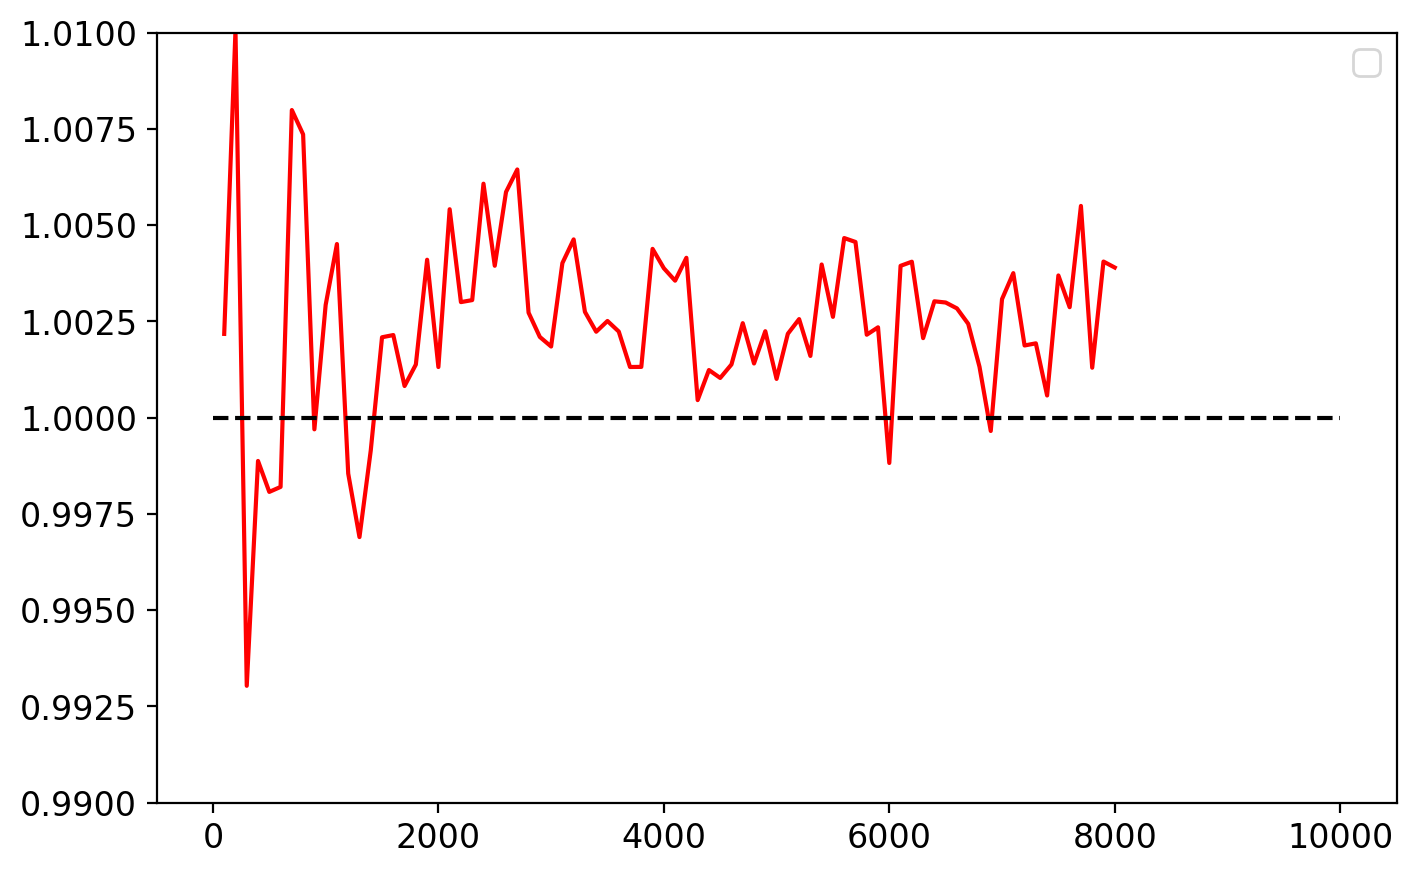

In [137]:
#plt.loglog(hp.alm2cl(y_kappa_lm), label = "y_kappa_lm")
#plt.plot(LC.get_AB_gaussian(Nfields-1, Nfields-1), label = "AB_gaussian")
#LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)
theory = clyy_official #LC.get_AB_gaussian(Nfields-1, Nfields-1)
#frac = hp.alm2cl(y_kappa_lm)[:theory.size]/theory
#frac[0] *= 0
#plt.plot(frac, label = "frac", alpha = 0.4)

bin_edges = np.arange(50, 8100, 100)
centst, dt = fgutils.simple_binning(theory, bin_edges)

cents, a = fgutils.simple_binning(hp.alm2cl(y_kappa_lm), bin_edges)
#cents, b = fgutils.simple_binning(hp.alm2cl(y_kappa_2048_lm), bin_edges)
plt.plot(cents, a/dt, color = "r")

#plt.plot(centsbefore, before, color = "g")

#cents, a = fgutils.simple_binning(hp.alm2cl(y_kappa_lm_high_l), bin_edges)
#cents, b = fgutils.simple_binning(hp.alm2cl(y_kappa_2048_lm), bin_edges)
#plt.plot(cents, a/dt, color = "b")

#plt.plot(cents, b/dt, color = "g")
plt.legend()
plt.ylim(0.99, 1.01)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")

In [127]:
#what happens if I generate Gaussian joint simulations??

In [112]:
from pixell import curvedsky, enmap, utils

In [113]:
clsG = np.zeros((Nfields, Nfields, 8192))

for i in range(Nfields-1):
    for j in range(Nfields-1):
        clsG[i+1, j+1] = LC.get_AB_gaussian(i, j)
    clsG[0, i+1] = LC.get_AB_gaussian(fixed_index, i)
    clsG[i+1, 0] = clsG[0, i+1]
clsG[0, 0] = LC.get_AB_gaussian(fixed_index, fixed_index)


In [114]:
almsC = curvedsky.rand_alm(clsG)

(0.9, 1.1)

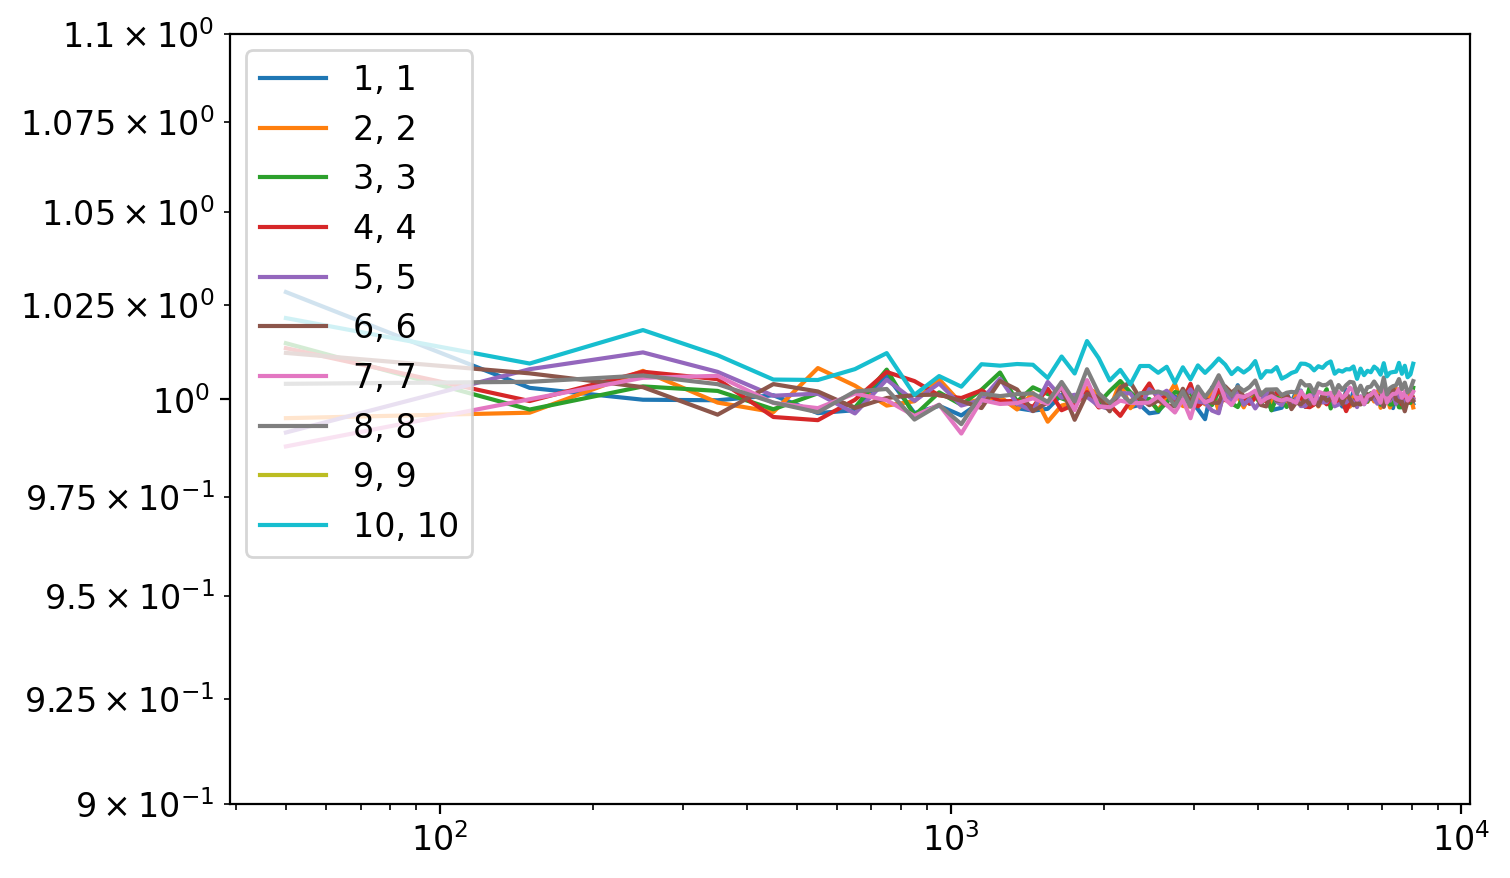

In [85]:

for i in range(1, len(lambdas)):
    for j in range(i, i+1):#len(lambdas)-1):
        #print(i, j)
        theory = clsG[i, j]
        centst, dt = fgutils.simple_binning(theory, bin_edges)
        cents, a = fgutils.simple_binning(hp.alm2cl(almsC_new[i], almsC_new[j]), bin_edges)
        plt.loglog(cents, a/dt, label = f"{i}, {j}")
        #plt.loglog(cents, dt, ls = "--")
plt.legend()
plt.ylim(0.9, 1.1)

In [138]:
rescale = clyy/clyy_official
y_kappa_lm_rescaled = y_kappa_lm #hp.almxfl(y_kappa_lm, rescale)

In [139]:
alms1 = LC_official._get_gaussian_alms(seed, y_kappa_lm_rescaled, None)
#alms2 = LC._get_gaussian_alms(seed, y_kappa_2048_lm, None)

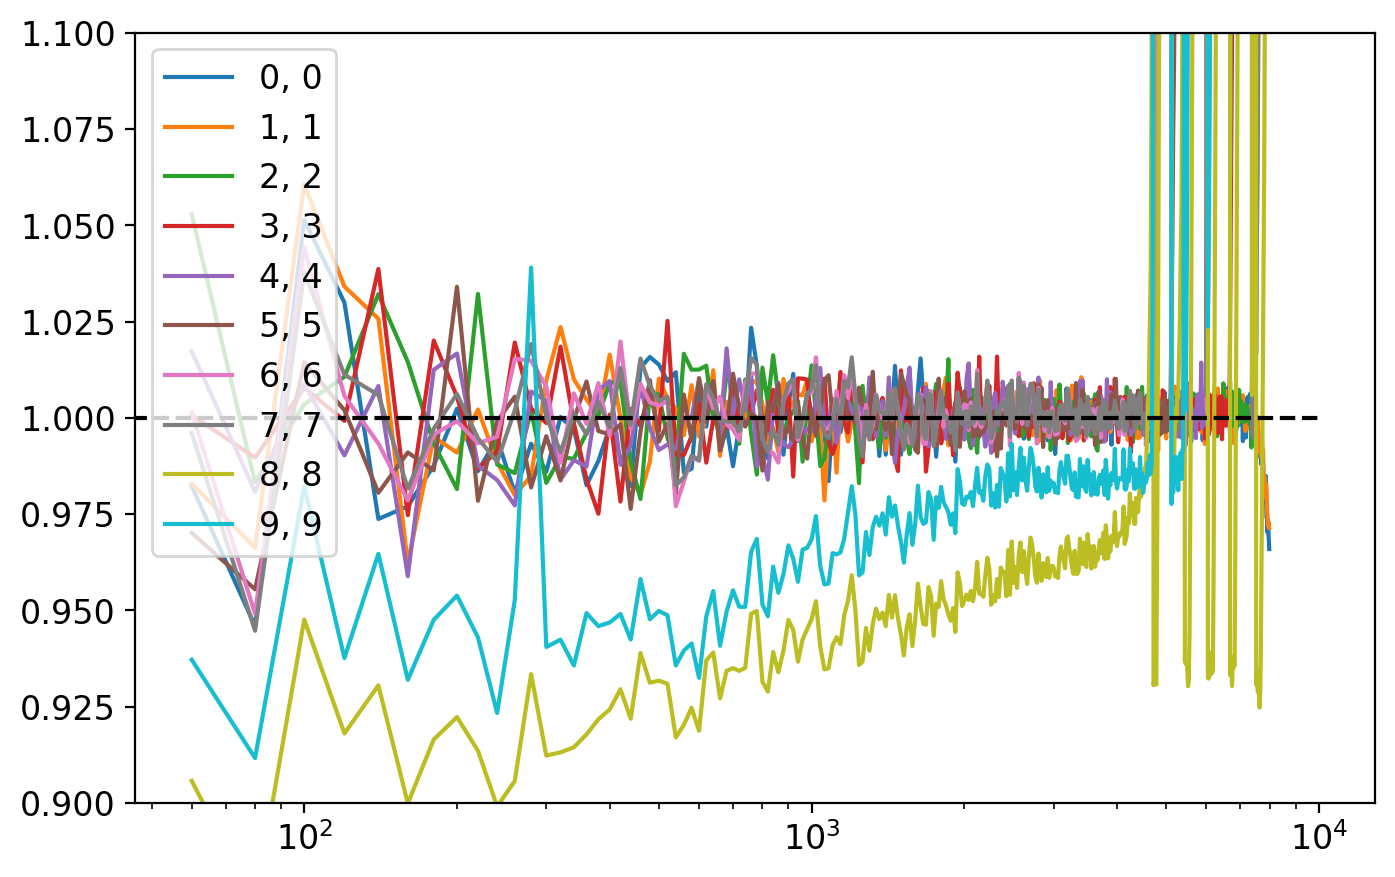

In [140]:
bin_edges = np.arange(50, 8000, 20)


for i in range(len(lambdas)-1):
    for j in range(i, i+1):#len(lambdas)-1):
        if i < 11:
            theory = LC.get_AB_gaussian(i, j)
            centst, dt = fgutils.simple_binning(theory, bin_edges)
            cents, a = fgutils.simple_binning(hp.alm2cl(alms1[i], alms1[j]), bin_edges)
            plt.plot(cents, a/dt, label = f"{i}, {j}")
        #plt.loglog(cents, dt, ls = "--")


"""for i in range(len(lambdas)-1):
    theory = LC.get_AB_gaussian(i, len(lambdas)-1)
    centst, dt = fgutils.simple_binning(theory, bin_edges)
    cents, a = fgutils.simple_binning(hp.alm2cl(alms1[i], y_kappa_lm), bin_edges)
    plt.plot(cents, a/dt, label = f"{i}")"""


#plt.plot(cents, b/dt, color = "g")
plt.legend()
plt.ylim(0.9, 1.1)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")
plt.xscale("log")

In [177]:
filter_modes = np.ones(9000)
filter_modes[7000:] = 0
alms1_ = [hp.almxfl(alm, filter_modes) for alm in alms1]

In [145]:
def get_maps(alms, nside_desired):
    alm2map = lambda alm: shts.alm2map(alm.copy(), nside_desired)
    maps_gaussian = list(map(alm2map, alms))
    vargauss = np.array([np.var(m) for m in maps_gaussian])
    expmu = (LC.means_of_fields_others+LC.lambda_others)*np.exp(-vargauss*0.5)
    mapsout = np.exp(maps_gaussian)
    mapsout *= expmu[..., None]
    mapsout -= LC.lambda_others[..., None]
    maps = np.array(mapsout)
    map2alm = lambda m: shts.map2alm(m.copy(), 3*nside_desired-1, nthreads = 32)
    result = list(map(map2alm, maps))
    return result, maps

In [146]:
nside_lognormal = 2048
#nside_lognormal = 4096

In [178]:
alms, maps = get_maps(alms1_, nside_lognormal)

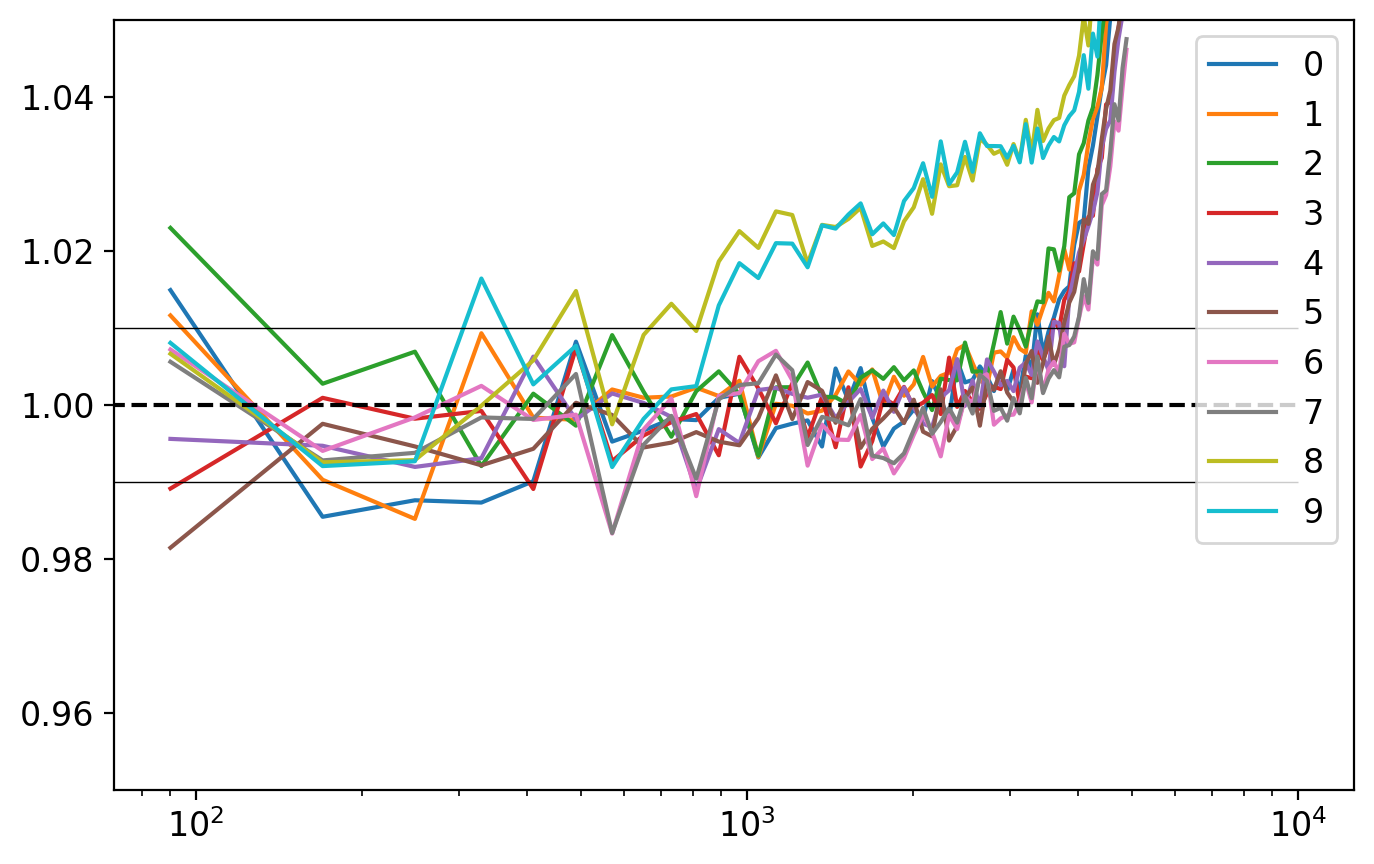

In [180]:
from plancklens import utils

bin_edges = np.arange(50, 5000, 80)

nside_ = nside_lognormal
for lmaxcommon in [6000]:
    #real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)
    #cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    #plt.plot(cents, a/dt, label = f"{lmax} - 8000")


    for x, alm in enumerate(alms):
        if True:
            theory = Getter(x, x)
            centst, dt = fgutils.simple_binning(theory, bin_edges)
            cents, a = fgutils.simple_binning(hp.alm2cl(alms[x]), bin_edges)
            plt.plot(cents, a/dt, label = f"{x}")

        if False:
            theory = Getter(x, fixed_index)
            centst, dtcross = fgutils.simple_binning(theory, bin_edges)
            lmax = hp.Alm.getlmax(alms[0].size)
            cents, a = fgutils.simple_binning(hp.alm2cl(utils.alm_copy(alm, lmaxcommon), utils.alm_copy(klm_full, lmaxcommon)), bin_edges)
            plt.plot(cents, a/dtcross, label = f"{x} - {fixed_index}")

    #real_lognormal_lm = hp.map2alm(real_lognormal_high, lmax = lmax)
    #cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    #plt.plot(cents, a/dt, color = "red", label = "High")

    """real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)
    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    plt.plot(cents, a/dt, color = "r")


    theory = Getter(0, 1)
    centst, dtcross = fgutils.simple_binning(theory, bin_edges)
    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm, utils.alm_copy(klm_full, lmax)), bin_edges)
    plt.plot(cents, a/dtcross, color = "g")
    """
"""cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_A_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "b")

cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_B_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "g")"""

plt.legend()
plt.ylim(0.95, 1.05)

plt.hlines(0.99, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1.01, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")
#plt.xlim(10, 5000)
plt.xscale("log")

In [37]:
lambdas

array([1.000e+01, 1.089e+00, 1.106e+00, 1.046e+00, 1.252e+00, 1.177e+00,
       1.177e+00, 4.530e-03, 8.850e-03, 2.100e-02, 3.300e-02])

In [248]:
"""Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)
Getter.cls = lgu.process_cl(Getter.cls, lsup = 9000, supindex = 30)
LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)

LChighell = lognormal.LognormalConditionedSims(Nfields-1, Gett_high_ell, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)


almG = hp.synalm(LC.get_AB_gaussian(0, 0)[:ll+1]) #8000, good number
ll = 8000
nside_ = 4096
real = hp.alm2map(utils.alm_copy(alms1[0], ll), nside = nside_, lmax = ll)
vargauss = np.var(real)
expmu = (LC.means_of_fields_others[0]+LC.lambda_others[0])*np.exp(-vargauss*0.5)
real_lognormal = np.exp(real)
real_lognormal *= expmu 
real_lognormal -= LC.lambda_others[0]
#nside_ = 2048
#lmax = 3*nside_-1
#lmax = 6000
#real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)"""

'Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)\nGetter.cls = lgu.process_cl(Getter.cls, lsup = 9000, supindex = 30)\nLC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)\n\nLChighell = lognormal.LognormalConditionedSims(Nfields-1, Gett_high_ell, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)\n\n\nalmG = hp.synalm(LC.get_AB_gaussian(0, 0)[:ll+1]) #8000, good number\nll = 8000\nnside_ = 4096\nreal = hp.alm2map(utils.alm_copy(alms1[0], ll), nside = nside_, lmax = ll)\nvargauss = np.var(real)\nexpmu = (LC.means_of_fields_others[0]+LC.lambda_others[0])*np.exp(-vargauss*0.5)\nreal_lognormal = np.exp(real)\nreal_lognormal *= expmu \nreal_lognormal -= LC.lambda_others[0]\n#nside_ = 2048\n#lmax = 3*nside_-1\n#lmax = 6000\n#real_lognormal_lm = hp.map2alm(real_l

In [249]:
"""Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)
Getter.cls = lgu.process_cl(Getter.cls, lsup = 9000, supindex = 30)
LC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)
Gett_high_ell = fgutils.SpectraGetter(cls_high_ell.copy(), fixed_index)
Gett_high_ell.cls = lgu.process_cl(Gett_high_ell.cls, lsup = 11000, supindex = 30)
LChighell = lognormal.LognormalConditionedSims(Nfields-1, Gett_high_ell, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)"""

'Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)\nGetter.cls = lgu.process_cl(Getter.cls, lsup = 9000, supindex = 30)\nLC = lognormal.LognormalConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)\nGett_high_ell = fgutils.SpectraGetter(cls_high_ell.copy(), fixed_index)\nGett_high_ell.cls = lgu.process_cl(Gett_high_ell.cls, lsup = 11000, supindex = 30)\nLChighell = lognormal.LognormalConditionedSims(Nfields-1, Gett_high_ell, realized_field_index = fixed_index, lambdas = lambdas, means_of_fields = np.repeat(mean_kappa, Nfields), set_negative_to_zero = False)'

In [250]:
"""plt.loglog(LC.get_AB_gaussian(0, 0))
plt.loglog(LChighell.get_AB_gaussian(0, 0))"""

'plt.loglog(LC.get_AB_gaussian(0, 0))\nplt.loglog(LChighell.get_AB_gaussian(0, 0))'

In [418]:
"""ll = 7000
almG = hp.synalm(LC.get_AB_gaussian(0, 0)[:ll]) #8000, good number
nside_ = 2048
real = hp.alm2map(almG, nside = nside_, lmax = ll-1)
vargauss = np.var(real)
expmu = (LC.means_of_fields_others[0]+LC.lambda_others[0])*np.exp(-vargauss*0.5)
real_lognormal_ = np.exp(real)
real_lognormal_ *= expmu 
real_lognormal_ -= LC.lambda_others[0]


ll_high = 11000
almG = hp.synalm(LChighell.get_AB_gaussian(0, 0)[:ll_high]) #8000, good number
nside_ = 4000
real = hp.alm2map(almG, nside = nside_, lmax = ll_high-1)
vargauss = np.var(real)
expmu = (LC.means_of_fields_others[0]+LC.lambda_others[0])*np.exp(-vargauss*0.5)
real_lognormal_high = np.exp(real)
real_lognormal_high *= expmu 
real_lognormal_high -= LC.lambda_others[0]"""

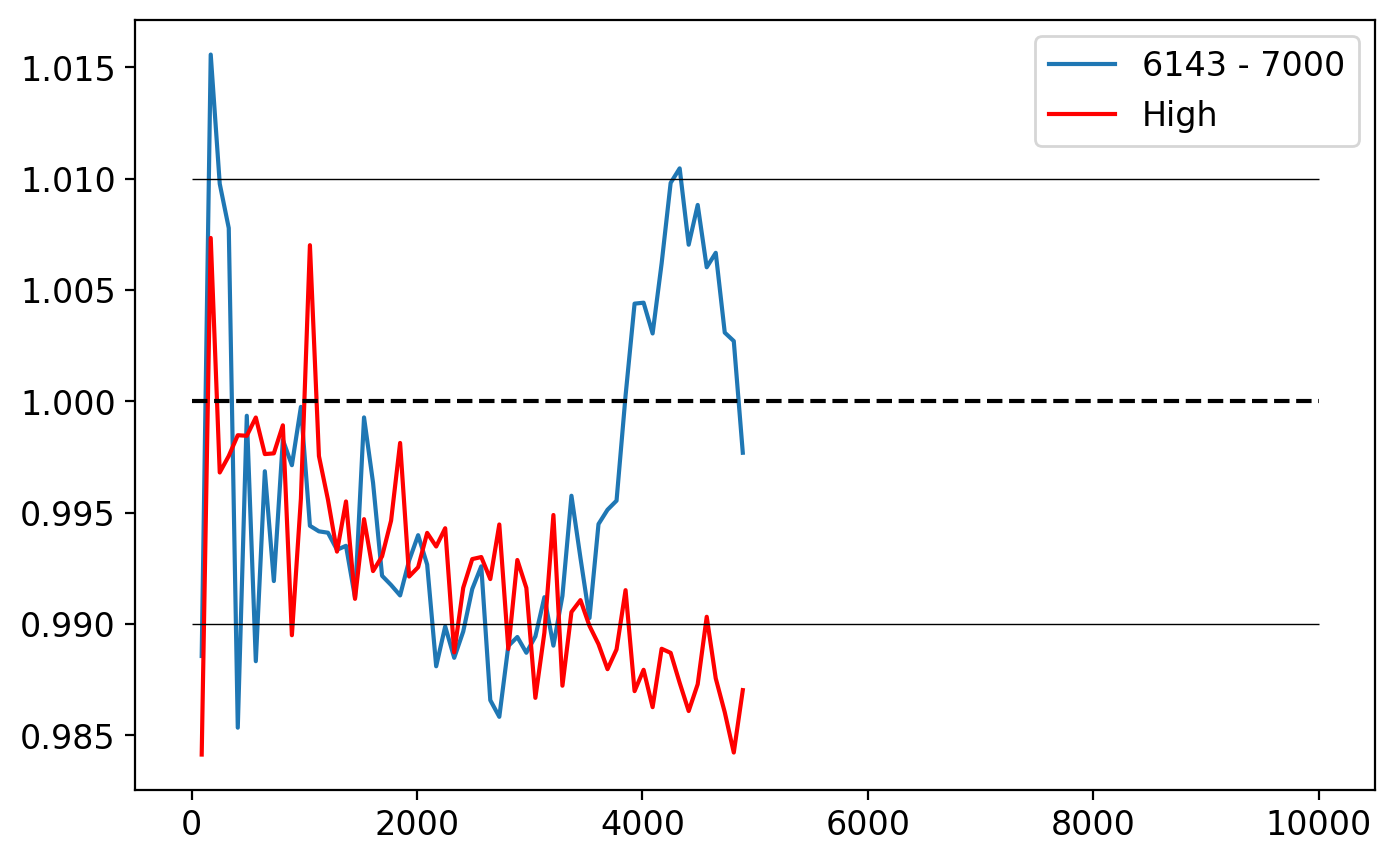

In [420]:
bin_edges = np.arange(50, 5000, 80)
theory = Getter(0, 0)
centst, dt = fgutils.simple_binning(theory, bin_edges)

nside_ = 2048
for lmax in [3*nside_-1]:
    #real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)
    #cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    #plt.plot(cents, a/dt, label = f"{lmax} - 8000")

    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    plt.plot(cents, a/dt, label = f"{lmax} - {ll}")

    #real_lognormal_lm = hp.map2alm(real_lognormal_high, lmax = lmax)
    #cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    #plt.plot(cents, a/dt, color = "red", label = "High")

    """real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)
    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    plt.plot(cents, a/dt, color = "r")


    theory = Getter(0, 1)
    centst, dtcross = fgutils.simple_binning(theory, bin_edges)
    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm, utils.alm_copy(klm_full, lmax)), bin_edges)
    plt.plot(cents, a/dtcross, color = "g")
    """
"""cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_A_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "b")

cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_B_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "g")"""

plt.legend()
#plt.ylim(0.98, 1.02)

plt.hlines(0.99, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1.01, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")
#plt.xlim(10, 5000)

In [325]:
#nn = 2048
#alms1 = LC._get_gaussian_alms(seed, y_kappa_lm, None)
#ll = 7000
#alms1[0] = utils.alm_copy(alms1[0], ll)
#alm_g_A_1, maps_out = get_maps(alms1, nn, 3*nn-1, ll)

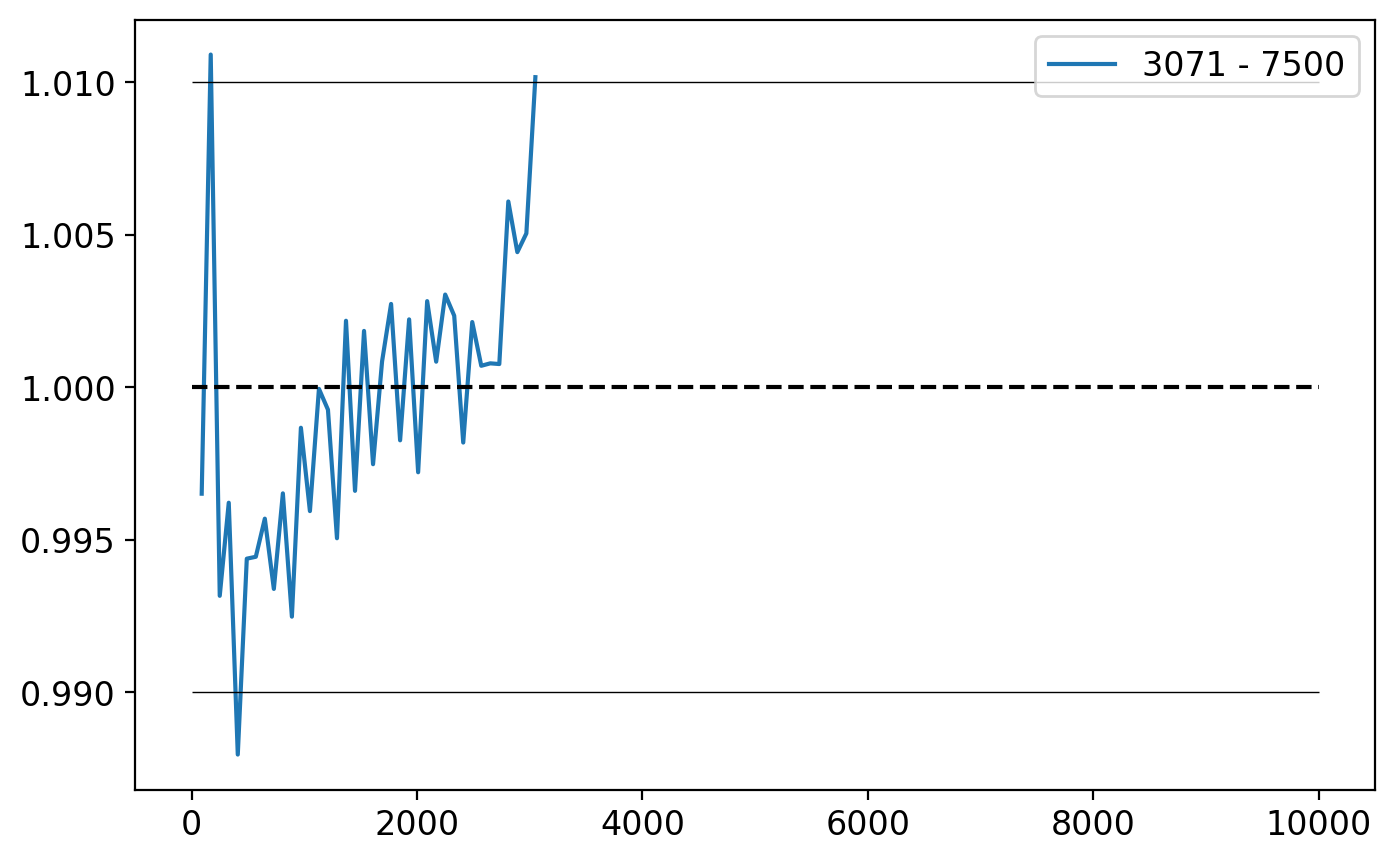

In [335]:
bin_edges = np.arange(50, 5000, 80)
theory = Getter(0, 0)
centst, dt = fgutils.simple_binning(theory, bin_edges)

#cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_A_1[0]), bin_edges)
#plt.plot(cents, a/dt, color = "r")

#cents, a = fgutils.simple_binning(hp.alm2cl(map_out_lm), bin_edges)
#plt.plot(cents, a/dt, color = "b")

nside_ = 1024
for lmax in [3*nside_-1]:
    #real_lognormal_lm = hp.map2alm(real_lognormal, lmax = lmax)
    #cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    #plt.plot(cents, a/dt, label = f"{lmax} - 8000")

    real_lognormal_lm = hp.map2alm(real_lognormal_, lmax = lmax)
    cents, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm), bin_edges)
    plt.plot(cents, a/dt, label = f"{lmax} - {ll}")

"""cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_A_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "b")

cents, a = fgutils.simple_binning(hp.alm2cl(alm_g_B_2[0]), bin_edges)
plt.plot(cents, a/dt, color = "g")"""

plt.legend()
#plt.ylim(0.98, 1.02)

plt.hlines(0.99, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1.01, 0, 10000, color = "k", lw = 0.5)
plt.hlines(1, 0, 10000, color = "k", linestyle = "--")
#plt.xlim(10, 5000)

In [61]:
#alms1 = LC._get_gaussian_alms(seed, y_kappa_lm, None)


In [51]:
#plt.loglog(hp.alm2cl(alms1[0])) #spike
#plt.loglog(hp.alm2cl(alms1_nside[0])) #spike
#plt.loglog(hp.alm2cl(alms2[0]))

In [ ]:
def get_maps(alms):
    alm2map = lambda alm: shts.alm2map(alm.copy(), nside)
    maps_gaussian = list(map(alm2map, alms))
    vargauss = np.array([np.var(m) for m in maps_gaussian])
    expmu = (LC.means_of_fields_others+LC.lambda_others)*np.exp(-vargauss*0.5)
    #mapsout = ne.evaluate('exp(maps_gaussian)')
    mapsout = np.exp(maps_gaussian)
    mapsout *= expmu[..., None]
    mapsout -= LC.lambda_others[..., None]
    maps = np.array(mapsout)
    map2alm = lambda m: shts.map2alm(m.copy(), lmax)
    result = list(map(map2alm, maps))
    return result, maps

#alms1, maps1 = get_maps(alms1)
alms2, maps2 = get_maps(alms2)

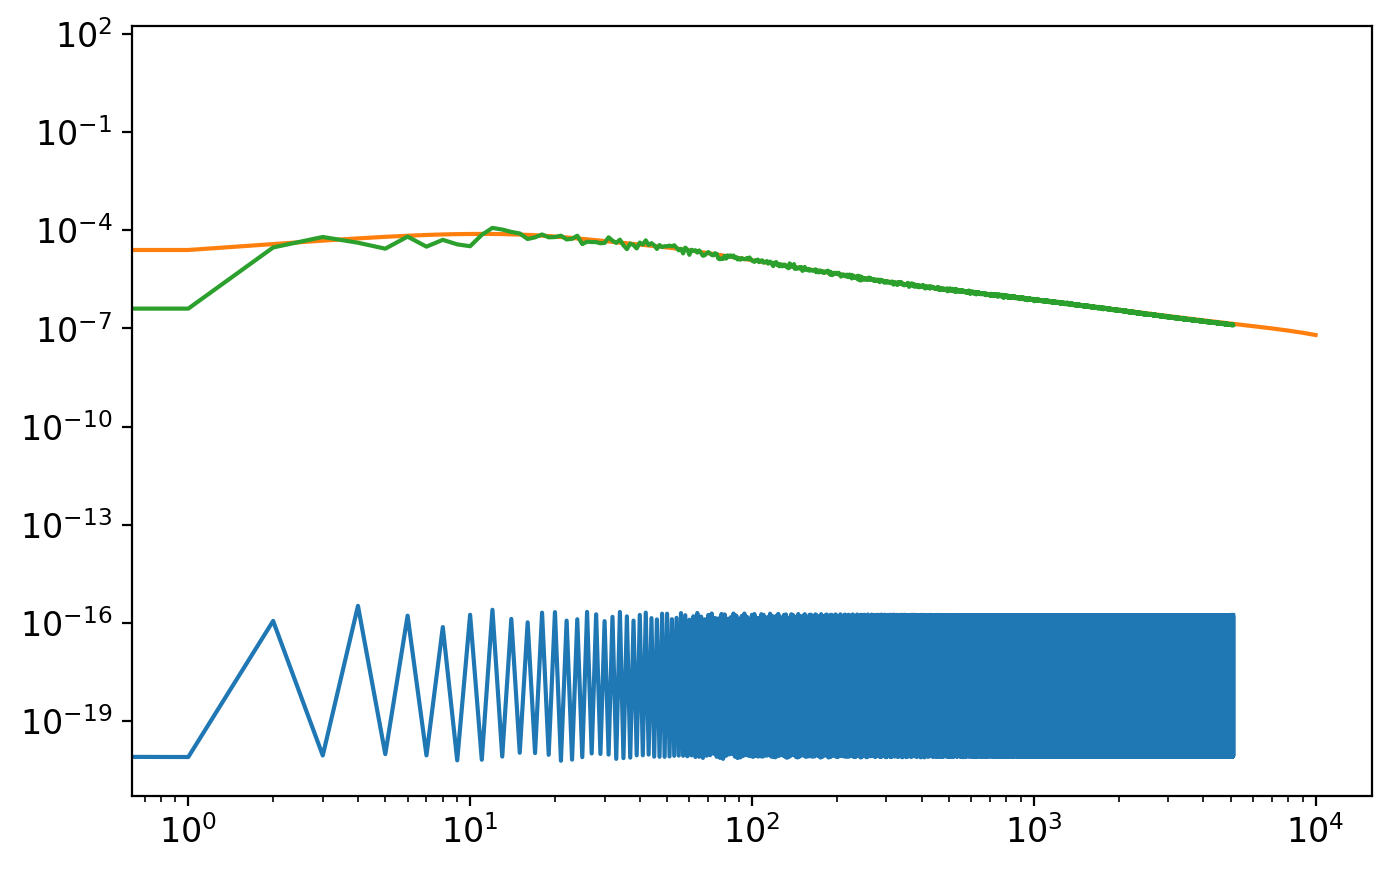

In [ ]:
plt.loglog(hp.alm2cl(alms1[0]))
theory_gg = LC.get_AB(0, 0)
plt.loglog(theory_gg)
plt.loglog(hp.alm2cl(alms2[0]))

(0.975, 1.1)

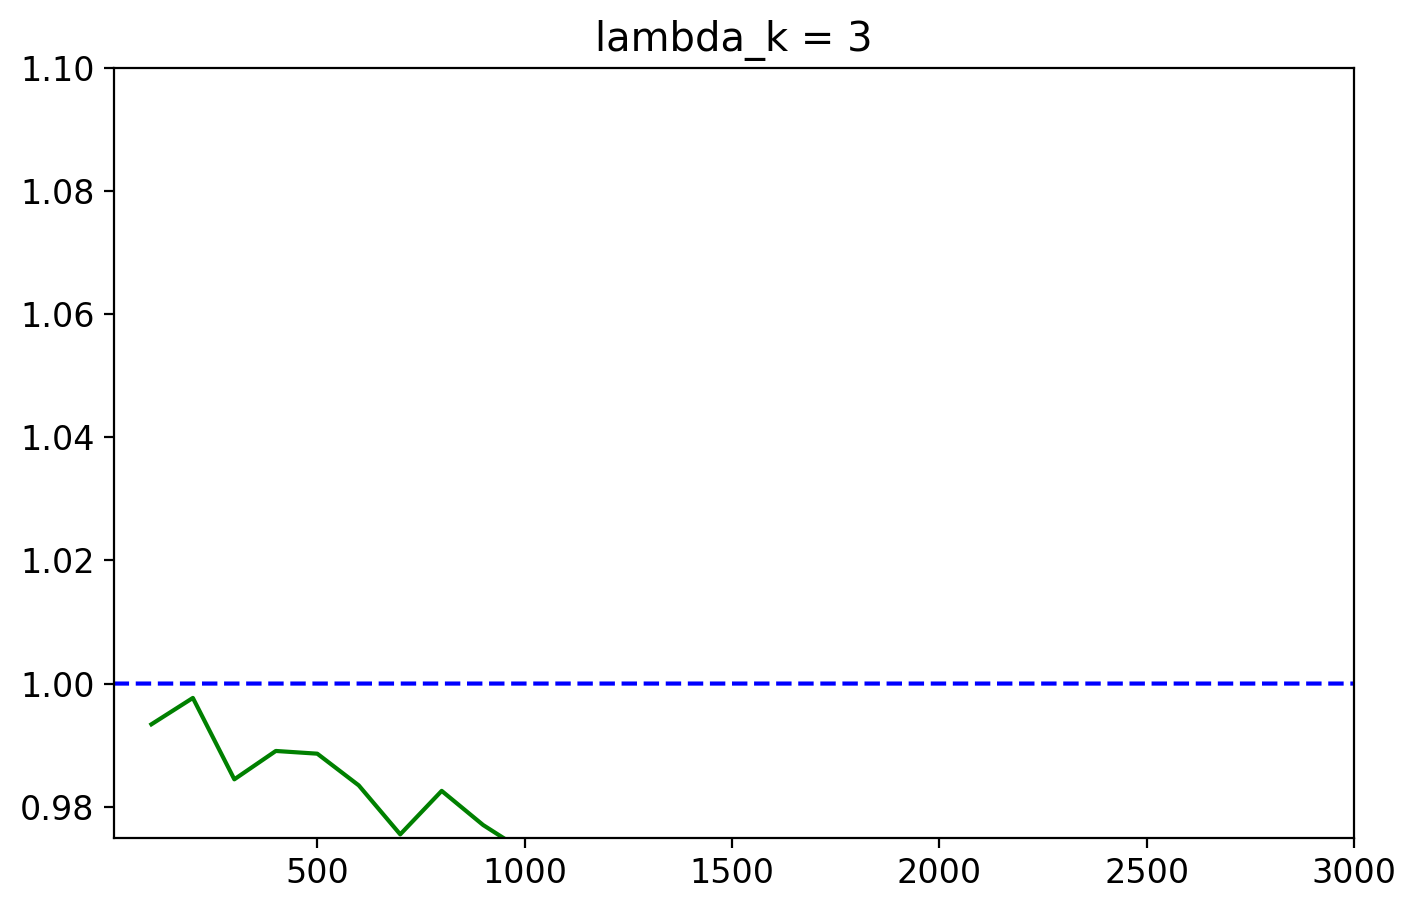

In [ ]:
plt.title(f"lambda_k = {lambda_k}")

theory_gg = LC.get_AB(0, 0)
plt.plot(theory_gg/theory_gg, color = "b", ls = "--")

bin_edges = np.arange(50, 3000, 100)
centst, dt = fgutils.simple_binning(theory_gg, bin_edges)

pixwin = hp.pixwin(nside)[:3*nside]

cents, a = fgutils.simple_binning(hp.alm2cl(alms[0]), bin_edges)
plt.plot(cents, a/dt, color = "r")


cents, a = fgutils.simple_binning(hp.alm2cl(alms2[0]), bin_edges)
plt.plot(cents, a/dt, color = "g")

plt.xlim(10, 3000)
plt.ylim(0.975, 1.1)

In [55]:
#plt.loglog(hp.alm2cl(alms[1]), label = "ss")
#plt.plot(LC.get_AB(1, 1), label = "ss")
#Getter = fgutils.SpectraGetter(cls.copy(), fixed_index)
#plt.plot(Getter(1, 1), ls = "--")


#plt.loglog(hp.alm2cl(alms[1], alms[0]))
#plt.plot(LC.get_AB(0, 1))

In [56]:
alms, maps = LC.generate_alm(seed, kappa, nside, out_real = True, process = True)#, cast_to_nside_lmax = True)

In [57]:
out_lambdas_other = [logutils.get_lambda_from_mappa(m) for m in maps]
print(out_lambdas_other/lambdas[1:]-1)

[nan]


/home/users/d/darwish/fieldgen/fieldgen/logutils.py:66: RuntimeWarning: invalid value encountered in sqrt
  lmbda = np.sqrt(var)/skew*(1+y_skew(skew)+1/y_skew(skew))-mu


In [58]:
#no suppression gives [-0.50051725  1.83736841], lambdak = 10
#with suppression and lambdak = 4 good results, [ 0.00174977 -0.00095604]

## Can also generate Gaussians

In [160]:
G = cs.ConditionedSims(Nfields-1, Getter, realized_field_index = fixed_index)
Galms = G.generate_alm(seed, klm)

In [161]:
Gmaps = [shts.alm2map(G.copy(), nside = nside) for G in Galms]

In [162]:
Gout_lambdas_other = [logutils.get_lambda_from_mappa(m) for m in Gmaps]
print(Gout_lambdas_other/lambdas[1:]-1)

[ -474.47522804 -1388.5108202 ]


## Let's get a reconstructed kappa

In [168]:
path = pathlib.Path("/home/users/d/darwish/scratch/ACTXDES-PROJECT/act_lensing_sims/")
kappa_alm = hp.read_alm(path/f"baseline/all_MV_simlensing_mf-sub_mc-corr_MV_{seed}.fits")

lensing_mask = hp.read_map(path/"masks/act_GAL060_mask_healpy_nside=2048.fits")
#mean preserved for nside
w2 = np.mean(lensing_mask**2)

kappa_alm /= w2

#just a simple w factor correction here for illustrative purposes

In [169]:
lmax_kappa = hp.Alm.getlmax(kappa_alm.size)
lmax_kappa

4000

In [170]:
lmaxkappa = hp.Alm.getlmax(klm.size)
lmaxkappa = lmax_kappa
mapsout_lm= [alm_copy(m, min(lmaxkappa, 3*nside-1)) for m in alms]

Gmapsout_lm = [alm_copy(m, min(lmaxkappa, 3*nside-1)) for m in Galms]

kappa_map = kappa_alm
klm_lm_copy = alm_copy(kappa_map, min(lmaxkappa, 3*nside-1))

cls_out_gg_cross = [hp.alm2cl(mapsout_lm[i], mapsout_lm[j]) for i in range(Nfields-1) for j in range(i, Nfields-1)]
cls_out_cross = [hp.alm2cl(mlm, klm_lm_copy) for mlm in mapsout_lm]

Gcls_out_gg_cross = [hp.alm2cl(Gmapsout_lm[i], Gmapsout_lm[j]) for i in range(Nfields-1) for j in range(i, Nfields-1)]
Gcls_out_cross = [hp.alm2cl(mlm, klm_lm_copy) for mlm in Gmapsout_lm]

kappa_map = klm
klm_lm_copy = alm_copy(kappa_map, min(lmaxkappa, 3*nside-1))
cls_out_cross_input = [hp.alm2cl(mlm, klm_lm_copy) for mlm in mapsout_lm]
Gcls_out_cross_input = [hp.alm2cl(mlm, klm_lm_copy) for mlm in Gmapsout_lm]

#Gcls_cls_cross = [hp.alm2cl(mG, m) for mG, m in zip(Gmapsout_lm, mapsout_lm)]

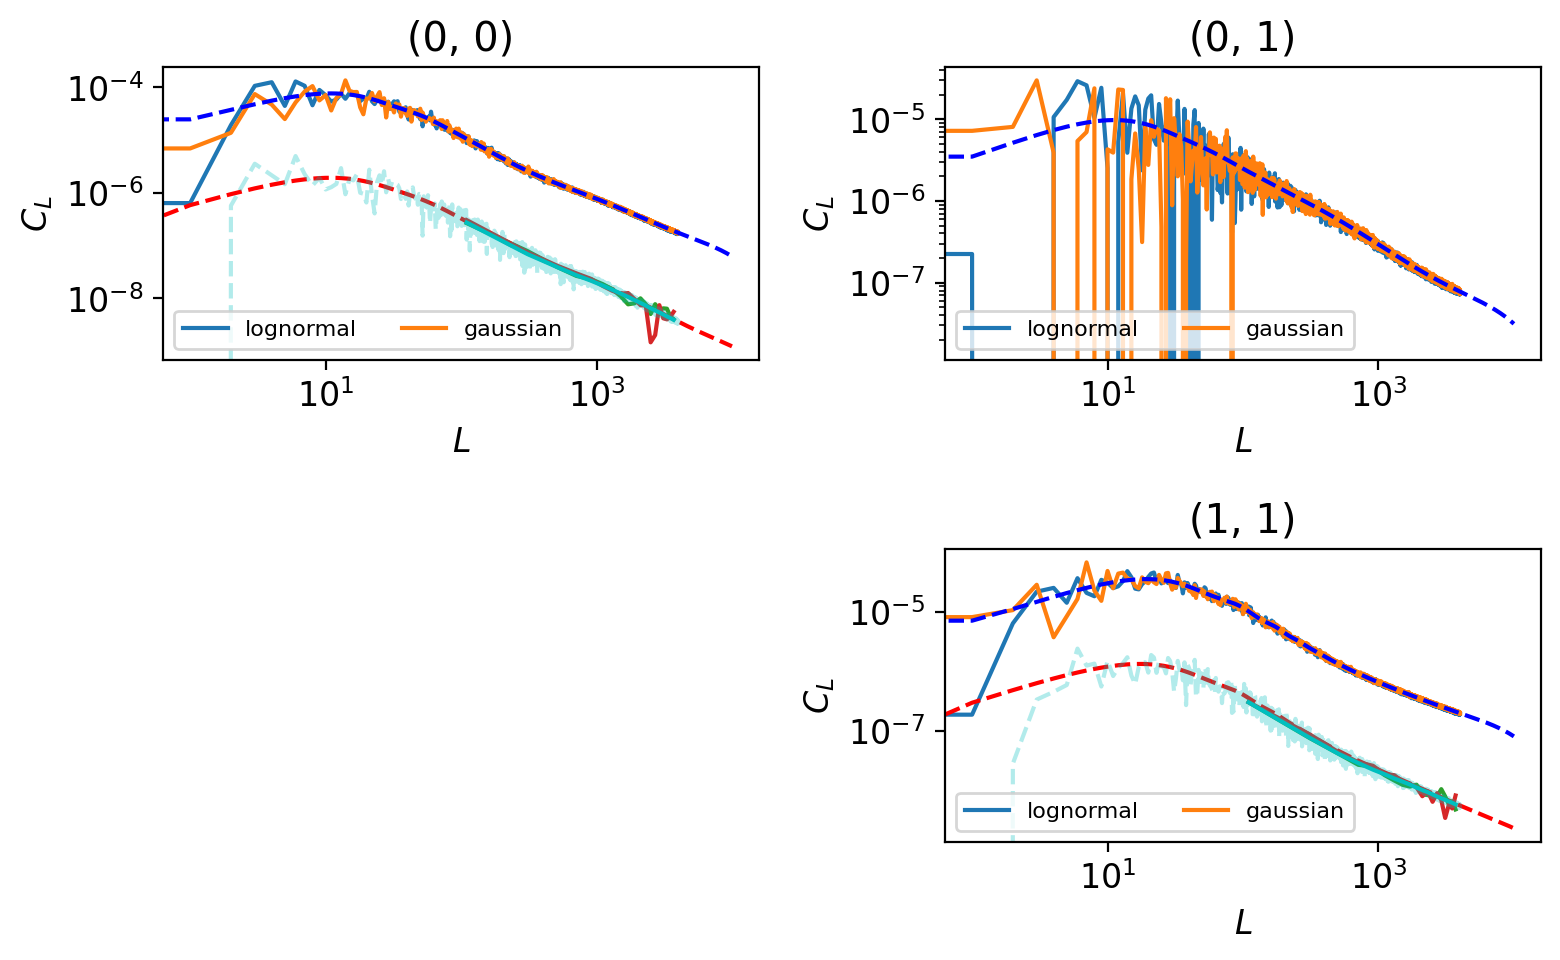

In [171]:
fig, ax = plt.subplots(Nfields-1, Nfields-1, figsize = (8, 5))
for i, j in np.ndindex(Nfields-1, Nfields-1):
    if i > j:
        ax[i, j].axis("off")
    else:

        #get index for cls
        index = i*(Nfields-1)+j-i*(i+1)//2

        ax[i, j].loglog(cls_out_gg_cross[index], label = "lognormal")
        ax[i, j].plot(Gcls_out_gg_cross[index], label = "gaussian")
        
        theory = LC.get_AB(i, j)
        ax[i, j].plot(theory, color = "b", ls = "--")

        if i == j:
            theory = LC.get_AB(i, fixed_index)
            ax[i, j].plot(theory, color = "r", ls = "--")

            lista = [cls_out_cross[i], Gcls_out_cross[i]]
            for l in lista:
                cents, d = fgutils.simple_binning(l)

                ax[i, j].plot(cents, d)
            
            cents, d = fgutils.simple_binning(cls_out_cross_input[i])
            ax[i, j].plot(cents, d, color = "c")
            ax[i, j].plot(cls_out_cross_input[i], color = "c", ls = "--", alpha = 0.3)


        ax[i, j].set_title(f"({i}, {j})")

        ax[i, j].set_xlabel(r"$L$")
        ax[i, j].set_ylabel(r"$C_L$")
        ax[i, j].legend(ncol = 2, fontsize = 8)
    
plt.tight_layout()

[0.98577717 1.01563433 0.99552824 0.98370656 0.98543275 0.98957255
 0.98899544 0.98909652 0.97980152 0.98525571 0.99084001 0.98892659
 0.9820239  0.98780243 0.98475501 0.97729735 0.98797698 0.97999434
 0.9845002  0.97758464 0.98411232 0.97905015 0.97836967 0.97072568
 0.9742593  0.96994553 0.97131438 0.97726333 0.96968378]
[0.88472127 0.98946113 1.00417829 0.97875148 0.99675838 0.96939749
 0.9707112  0.98367985 0.96225582 0.97529101 0.98193436 0.97769599
 0.96458723 0.98084411 0.96790785 0.97085644 0.98494251 0.97092497
 0.97231472 0.96081987 0.97985115 0.97153813 0.96971718 0.95952047
 0.96316504 0.96243473 0.97113059 0.97226548 0.96201857]
[0.99024997 0.9906251  0.9941471  0.98765586 0.98239114 0.96833653
 0.97196541 0.9802507  0.98105872 0.98012024 0.97735727 0.9837002
 0.97210739 0.97577165 0.97387061 0.97422655 0.97716085 0.97099659
 0.9693399  0.96778199 0.974167   0.96976041 0.96735449 0.96983626
 0.96710998 0.96775417 0.96897553 0.96726254 0.96665002]


/tmp/ipykernel_3104604/289022443.py:25: RuntimeWarning: invalid value encountered in true_divide
  ax[i, j].plot(theory_kg/theory_kg, color = "r", ls = "--")


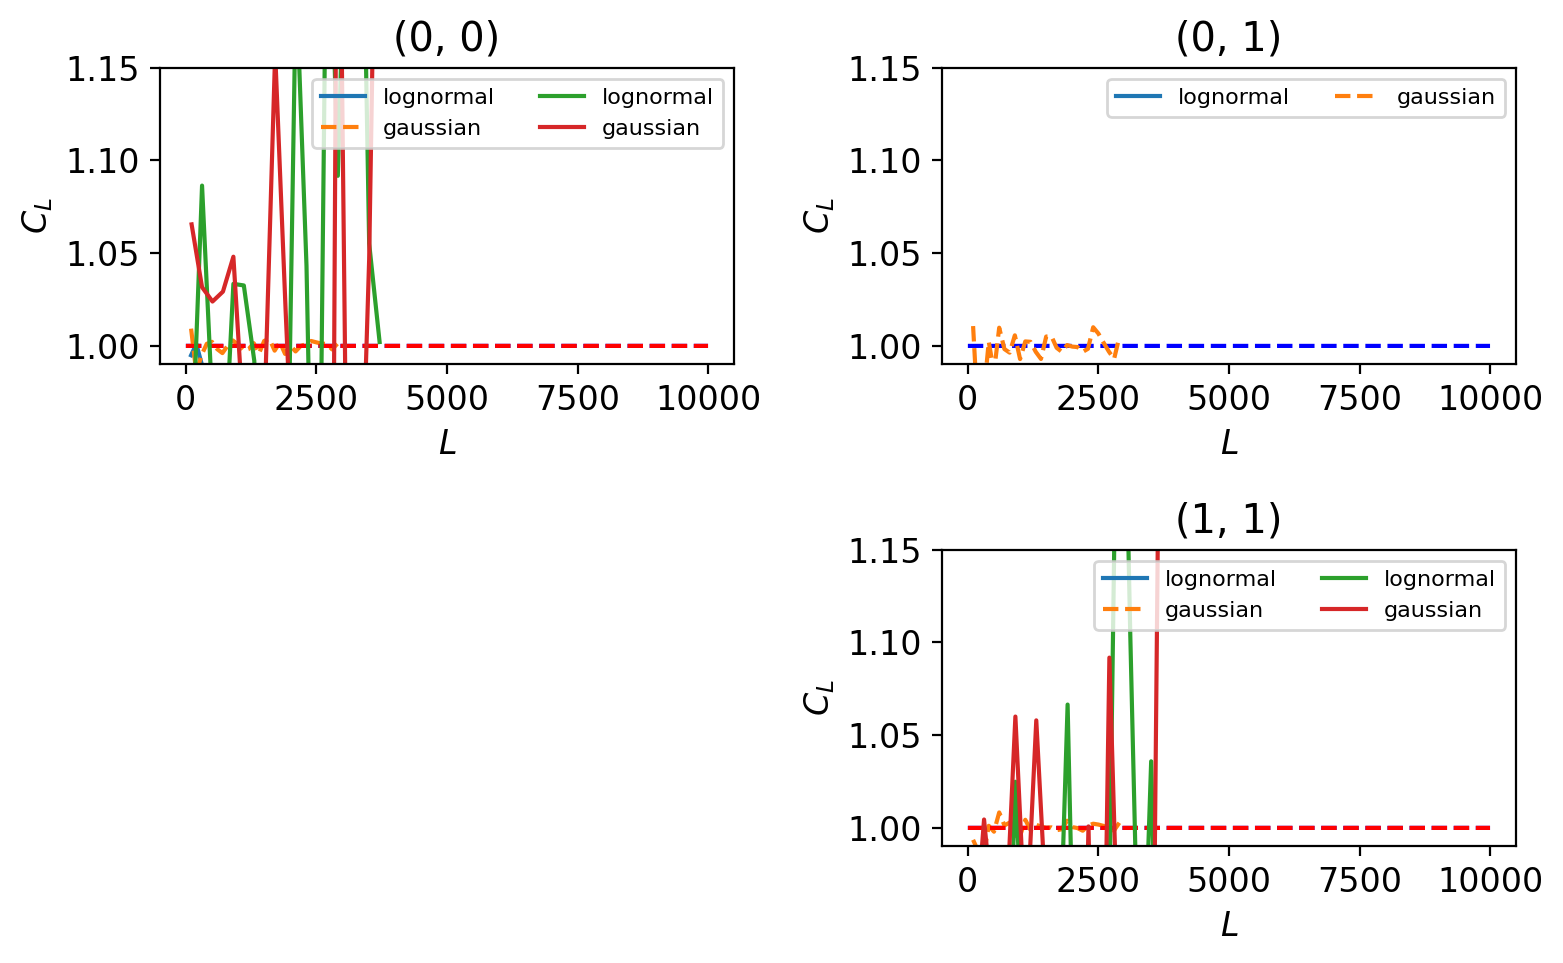

In [172]:
fig, ax = plt.subplots(Nfields-1, Nfields-1, figsize = (8, 5))
for i, j in np.ndindex(Nfields-1, Nfields-1):
    if i > j:
        ax[i, j].axis("off")
    else:

        #get index for cls
        index = i*(Nfields-1)+j-i*(i+1)//2

        theory_gg = LC.get_AB(i, j)
        ax[i, j].plot(theory_gg/theory_gg, color = "b", ls = "--")

        bin_edges = np.arange(50, 3000, 100)
        centst, dt = fgutils.simple_binning(theory_gg, bin_edges)

        cents, a = fgutils.simple_binning(cls_out_gg_cross[index], bin_edges)
        ax[i, j].plot(cents, a/dt, label = "lognormal")
        cents, b = fgutils.simple_binning(Gcls_out_gg_cross[index], bin_edges)
        ax[i, j].plot(cents, b/dt, label = "gaussian", ls = "--")

        print(a/b)
    
        if i == j:
            theory_kg = LC.get_AB(i, fixed_index)
            ax[i, j].plot(theory_kg/theory_kg, color = "r", ls = "--")

            lista = [cls_out_cross[i], Gcls_out_cross[i]]
            for l, lab in zip(lista, ["lognormal", "gaussian"]):
                cents, d = fgutils.simple_binning(l)
                centst, dt = fgutils.simple_binning(theory_kg)

                ax[i, j].plot(cents, d/dt, label = lab)
            
            #cents, d = fgutils.simple_binning(cls_out_cross_input[i])
            #ax[i, j].plot(cents, d, color = "c")
            #ax[i, j].plot(cls_out_cross_input[i], color = "c", ls = "--", alpha = 0.3)


        ax[i, j].set_title(f"({i}, {j})")

        ax[i, j].set_xlabel(r"$L$")
        ax[i, j].set_ylabel(r"$C_L$")
        ax[i, j].legend(ncol = 2, fontsize = 8)
        ax[i, j].set_ylim(0.99, 1.15)
    
plt.tight_layout()

### Let's just check the noiseless input for simple binning

Not perfect, but can be improved.

Text(0, 0.5, '$C_L$')

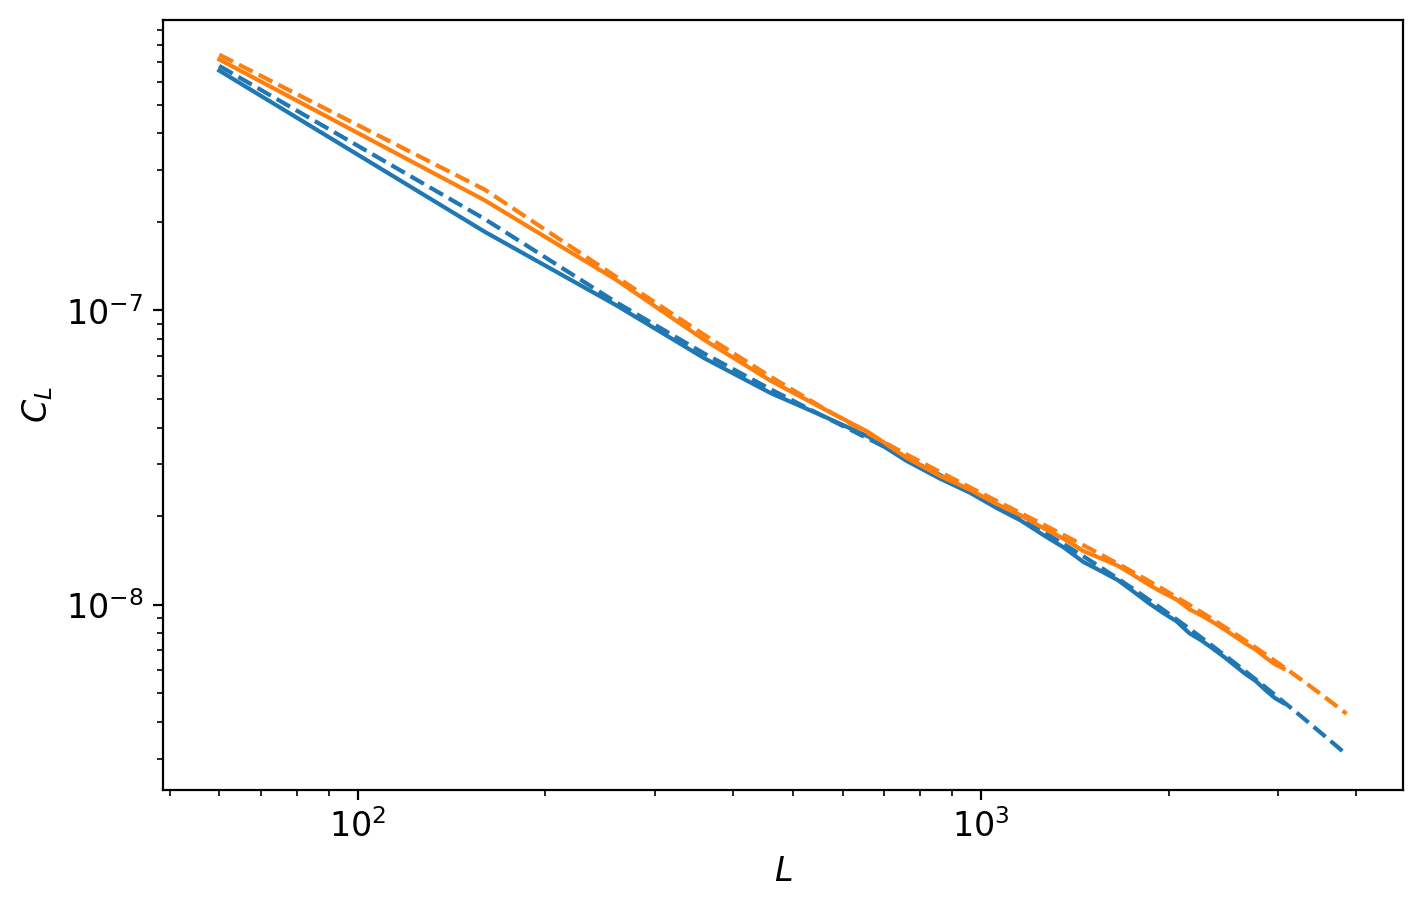

In [17]:
binning = np.arange(10, 4000, 100)
for i in range(Nfields-1):
    theory = LC.get_AB(i, fixed_index)
    cents, d = fgutils.simple_binning(theory, binning)
    p = plt.plot(cents, d, ls = "--")
    cents, d = fgutils.simple_binning(cls_out_cross_input[i], binning)
    plt.loglog(cents, d, color = p[0].get_color())



plt.xlabel(r"$L$")
plt.ylabel(r"$C_L$")


## Populate

Now we generate Poisson sampled simulations.

For a Gaussian field use $\alpha < 1$. For lognormal, just unity.

In [23]:
from fieldgen import catutils

weights = np.ones(Nfields-1)

Nobs = [150000, 222000]

mask = np.ones_like(maps[0])

alpha = 0.9

counts = [catutils.delta_g_to_number_counts(delta_g_input_real = deltag, No_observed = No, seed = seed, mask = mask, weights = 1, alpha = alpha) for deltag, No in zip(maps, Nobs)]

columns = catutils.get_catalog(seed = seed, Npix = len(mask), nside = nside, number_counts = counts, z = 0, nz = 0, sample_z = False)

#columnsnames = ['RA', 'DEC', 'Z', 'ZBIN', 'WEIGHT']
#catutils.save_catalog(filename = self.directory/f'{filename}.fits', columnsnames = columnsnames, columns = columns)

In [24]:
counts_means = [np.mean(counts_) for counts_ in counts]
delta_contrast_counts = [(counts_ - counts_mean)/counts_mean for counts_, counts_mean in zip(counts, counts_means)]
delta_alm = [shts.map2alm(delta_contrast_counts_.copy(), lmax = lmax) for delta_contrast_counts_ in delta_contrast_counts]

In [27]:
lmaxkappa = hp.Alm.getlmax(klm.size)
mapsout_lm = [alm_copy(m, min(lmax, 3*nside-1)) for m in delta_alm]

kappa_map = kappa_alm
klm_lm_copy = alm_copy(kappa_map, min(lmax, 3*nside-1))

cls_out_gg_cross = [hp.alm2cl(mapsout_lm[i], mapsout_lm[j])/alpha**2. for i in range(Nfields-1) for j in range(i, Nfields-1)]
cls_out_cross = [hp.alm2cl(mlm, klm_lm_copy)/alpha for mlm in mapsout_lm]

kappa_map = klm
klm_lm_copy = alm_copy(kappa_map, min(lmax, 3*nside-1))
cls_out_cross_input = [hp.alm2cl(mlm, klm_lm_copy)/alpha for mlm in mapsout_lm]

#Gcls_cls_cross = [hp.alm2cl(mG, m) for mG, m in zip(Gmapsout_lm, mapsout_lm)]

/Users/omard/Documents/projects/fieldgen/fieldgen/utils.py:65: RuntimeWarning: invalid value encountered in divide
  cl = cl[0] / sums[0]


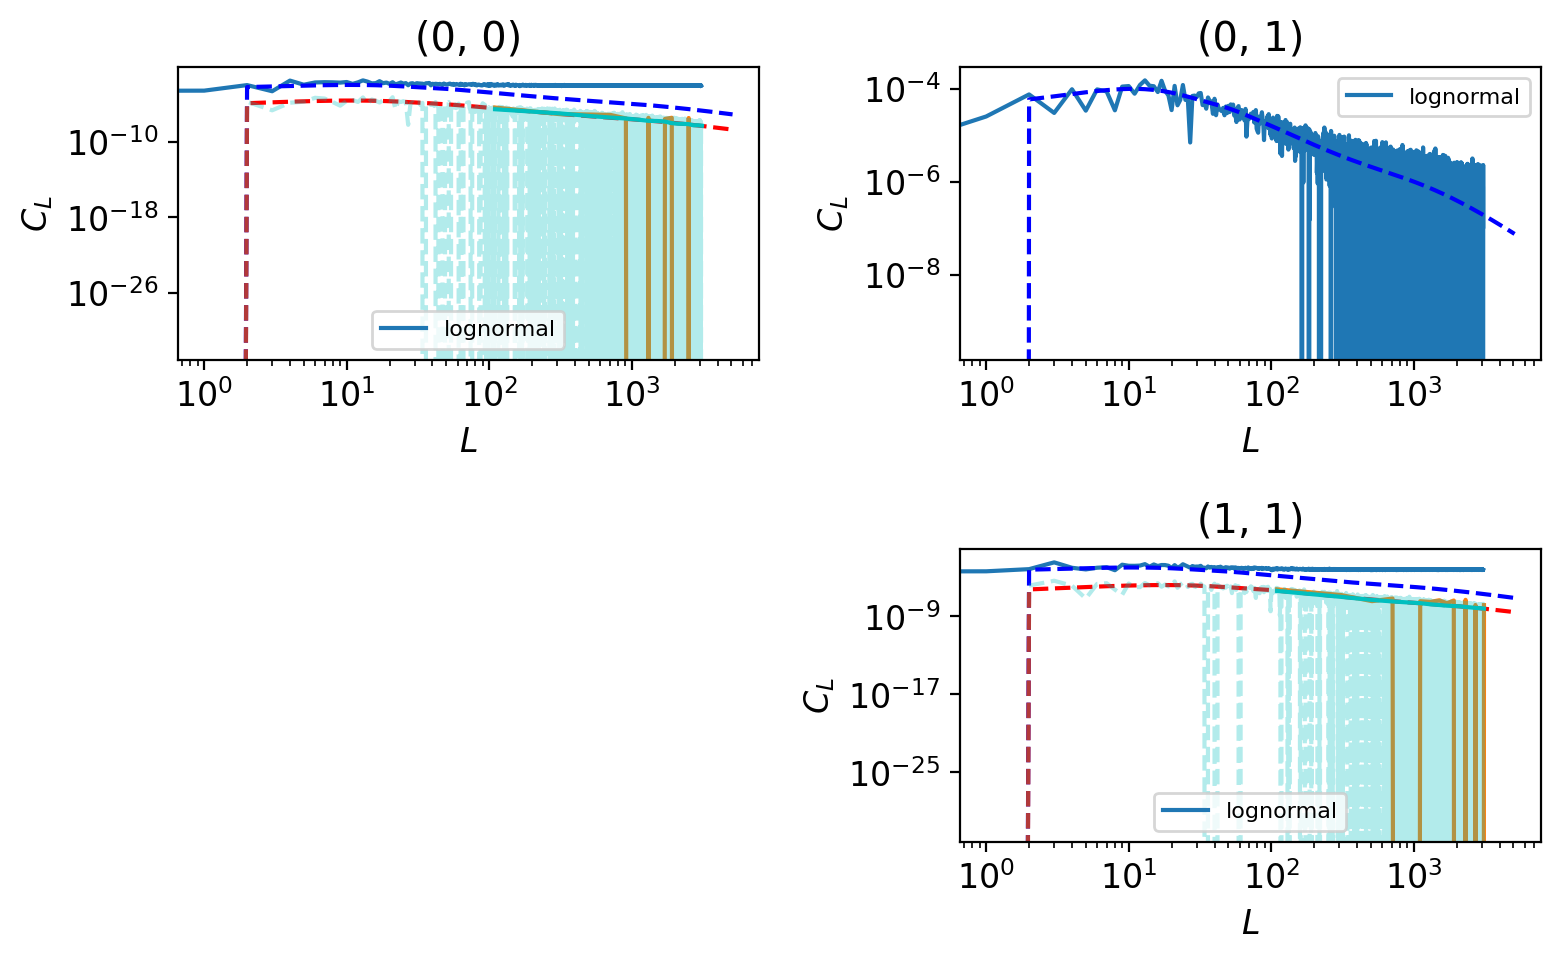

In [28]:
fig, ax = plt.subplots(Nfields-1, Nfields-1, figsize = (8, 5))
for i, j in np.ndindex(Nfields-1, Nfields-1):
    if i > j:
        ax[i, j].axis("off")
    else:

        #get index for cls
        index = i*(Nfields-1)+j-i*(i+1)//2

        ax[i, j].loglog(cls_out_gg_cross[index], label = "lognormal")
        
        theory = LC.get_AB(i, j)
        ax[i, j].plot(theory, color = "b", ls = "--")

        if i == j:
            theory = LC.get_AB(i, fixed_index)
            ax[i, j].plot(theory, color = "r", ls = "--")

            lista = [cls_out_cross[i]] #, Gcls_out_cross[i]]
            for l in lista:
                cents, d = fgutils.simple_binning(l)

                ax[i, j].plot(cents, d)
            
            cents, d = fgutils.simple_binning(cls_out_cross_input[i])
            ax[i, j].plot(cents, d, color = "c")
            ax[i, j].plot(cls_out_cross_input[i], color = "c", ls = "--", alpha = 0.3)


        ax[i, j].set_title(f"({i}, {j})")

        ax[i, j].set_xlabel(r"$L$")
        ax[i, j].set_ylabel(r"$C_L$")
        ax[i, j].legend(ncol = 2, fontsize = 8)
    
plt.tight_layout()